# Embeddings to Occupational Space

## Pipeline summary (PCA → polar occupation space, strict run)

This notebook segment **reconstructs a 2D “occupation space” from task embeddings** in the *currently active embeddings run*, then derives **task-, occupation-, and job-family–level coordinates** in both a canonical PC-plane and a **polarized representation** ((\xi,\chi)). It also performs **optional rotational/reflection alignment** to a stored reference and exports **geometry + quality diagnostics** for downstream analysis and plotting.

### 1) Strict run activation and configuration

* Reloads project modules (`infra`, `embeddings`), **activates the most recent run** (fails if none), and loads **run-local configuration** (`year`, `onet_version`, `encoder_name`, encoder id).
* Sets a single **global seed** (`SEED=42`) and defines notebook parameters controlling PCA, radial scaling, and sectorization:

  * PCA: optional common-component removal, optional centering, optional RLE-based weights, 2 components.
  * Polar mapping: (\xi) from angle in the PC-plane (with optional rotation), (\chi) from a fitted radial scale.
  * Discretization: `N_SECTORS` angular bins and `CHI_BINS` radial zones.

### 2) Strict input loading and embedding integrity

* Loads run exports: `tasks_for_pca_base.csv`, `task_embeddings.npy`, and `task_embeddings_fingerprint.json`.
* Validates that the **task texts and embedding matrix match the run fingerprint**, ensuring reproducibility and preventing silent drift.

### 3) Core numeric toolkit

Defines reusable helpers for:

* **(Weighted) PCA** on embeddings, with an optional **common-component subtraction** (via 1D `TruncatedSVD`) and optional **RLE-derived weights**.
* **Polar/Cartesian conversions** and a `RadialScale` abstraction that maps metric radius (r) to plot radius (\chi) using `minmax`, `zero_max`, or quantile scaling (optionally clipped).
* **Sector/zone labels** from (\xi) and (\chi).
* A general **orthogonal 2×2 transform** utility (rotation/reflection) for applying alignment transforms in-place.

### 4) PCA with deterministic caching

* Builds a **cache key** from: the run’s embedding fingerprint + PCA parameters (weights summary, centering, remove-common, component count, shapes/dtypes).
* Loads cached PCA results if (and only if) the stored signature matches; otherwise computes PCA and stores:

  * `XY` (task scores), `V` (loadings), `mu` (center), `var_ratio`.

### 5) Tasks → polar coordinates and discretization

* Writes task scores to `df_tasks` (`pc1`, `pc2`), then constructs:

  * (r=\sqrt{pc1^2+pc2^2})
  * (\xi = \mathrm{atan2}(pc2,pc1)+\mathrm{SECTOR_ROTATION} \pmod{2\pi})
  * (\chi = \mathrm{RadialScale}(r)) (global scale fitted from all tasks)
* Assigns each task to an **angular sector** and **radial zone**, and creates a combined `sector_zone` label.
* Performs a fail-fast check that ((\xi,r)) reconstructs the original ((pc1,pc2)) numerically (i.e., (\chi) is *not* used metrically).

### 6) Occupation and job-family centers (RT-weighted, then equal-occ)

* Builds `df_occ` (occupation centers) by aggregating tasks in the **canonical PC-plane**:

  * Centers are **RT-weighted means** of `(pc1, pc2)` using either **all tasks** or **core-only tasks** (`OCC_CENTER_TASKS`).
  * Adds metadata (`Title`, `Job Family`) from task-level mappings (geometry remains independent of labels).
  * Derives ((\xi,r,\chi)) and sector/zone labels for occupations from their PC-centers.
* Builds `df_fam` (job-family centers) by aggregating **occupation centers with equal weight per occupation** (not proportional to number of tasks):

  * Adds `n_occ_used` and computes a **directionality / angular concentration** statistic (R) for family (\xi) dispersion (`xi_concentration_R`).

### 7) Optional xi-only alignment to a stored reference

* If a reference file exists (`data/procrustes_ref_occupation_embeddings_polar_scaled.csv`), aligns the embedding plane to it using **only angular information**:

  * Fits either **rotation** (\xi_{\text{ref}}\approx \xi_{\text{cur}}+\delta) or **reflection+rotation** (\xi_{\text{ref}}\approx -\xi_{\text{cur}}+\delta), choosing the lower circular RMSE.
  * Applies the resulting **orthogonal transform** to `(pc1, pc2)` for tasks/occupations/families, then recomputes derived polar and sector/zone labels.
  * Stores alignment metadata (`delta`, `reflect`, `det(R)`, RMSE before/after, number of common occupations).

### 8) Exports (schema-preserving) and quality diagnostics

* Exports full-column, key-first CSVs to the **current run’s `exports/`**:

  * `task_embeddings_polar_scaled.csv`
  * `occupation_embeddings_polar_scaled.csv`
  * `job_family_centers_polar_scaled.csv`
* Computes and exports **embedding quality diagnostics**:

  * **Within-occupation task spread**: distances from tasks to occupation center (unweighted + RT-weighted).
  * **Between-occupation separation index**: mean inter-occupation distance divided by mean within-occupation spread.
  * **kNN sanity**: for each occupation, share of its (k) nearest neighbors in the same job family.
  * **Within-family occupation spread** and family **directionality (R)** summary.
  * Exports: overview row, per-occupation table, per-family table, plus a JSON meta definition bundle.

### 9) Visualization outputs (polar map and small multiples)

* Produces a **global polar map** showing sampled tasks (core vs supplemental), occupations colored by job family, and labeled family centers; saves as PNG/PDF under `figures/`, and exports plot-ready rows to `polar_plot_data.csv`.
* Produces **small multiples**: one polar subplot per job family with tasks, occupations, and a robust family center marker; saves PNG/PDF.

In short: the code takes **run-validated task embeddings**, computes a **reproducible cached PCA**, maps tasks/occupations/families into a **canonical 2D plane** and a **polarized occupation space** with sectors/zones, optionally **aligns orientation to a reference**, and exports both **geometry** and **compact quality diagnostics** for analysis and publication-ready plotting.


In [1]:
# === Cell 1: Setup & activate last run (STRICT) ===

import importlib
import numpy as np

import infra
import embeddings  # noqa: F401 (imported for side effects / API availability)

importlib.reload(infra)
importlib.reload(embeddings)

# Activate last run explicitly (strict: errors if none)
infra.activate_last_run(echo=False)

# Load config + encoder spec for the active run (does not create a new run)
RP, cfg, ENCODER_SPEC = infra.load_embeddings_run(strict=True)

# Reproducibility (one place only)
SEED = 42
np.random.seed(SEED)

# Read run parameters from config (single source of truth)
YEAR = int(cfg.get("year", 2025))
ONET_VERSION = str(cfg.get("onet_version", "30_0"))
ENCODER_NAME = str(cfg.get("encoder_name", "")).strip()

print("PROJECT_ROOT :", infra.PROJECT_ROOT)
print("RUNS_ROOT    :", infra.RUNS_ROOT)
print("RUN_TAG      :", infra.RUN_TAG)
print("RUN_DIR      :", infra.RUN_DIR)
print("Exports      :", RP.exports)
print("Cache (run)  :", RP.cache)
print("Cache (glob) :", infra.GLOBAL_CACHE_ROOT)
print("YEAR         :", YEAR)
print("ONET_VERSION :", ONET_VERSION)
print("ENCODER_NAME :", ENCODER_NAME)
print("ENCODER_ID   :", ENCODER_SPEC.embedder_id())
print("SEED         :", SEED)


PROJECT_ROOT : /home/joc/code/geometry-of-work
RUNS_ROOT    : /home/joc/code/geometry-of-work/out/runs
RUN_TAG      : embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1
RUN_DIR      : /home/joc/code/geometry-of-work/out/runs/embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1
Exports      : /home/joc/code/geometry-of-work/out/runs/embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1/exports
Cache (run)  : /home/joc/code/geometry-of-work/out/runs/embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1/cache
Cache (glob) : /home/joc/code/geometry-of-work/out/_cache
YEAR         : 2025
ONET_VERSION : 30_1
ENCODER_NAME : openai-3-large
ENCODER_ID   : openai:text-embedding-3-large?dim=3072
SEED         : 42


In [2]:
# === Cell 1b: Notebook config (PCA/polar) ===
import numpy as np
RANDOM_STATE = SEED

# Pre-PCA embedding scaling
SCALER_MODE = "none"        # {"none", "rle", "rt"}
SCALER_FN = "log"          # {"linear", "log", "sqrt"}

REMOVE_COMMON = False
PCA_CENTER = True
N_PCA_COMPONENTS = 3
RADIAL_MODE = "zero_max"
RADIAL_PLOW = 0.05
RADIAL_PHIGH = 0.95
RADIAL_CLIP = True
N_SECTORS = 36
SECTOR_ROTATION = 0.0
CHI_BINS = [0.0, 0.33, 0.66, np.inf]
OCC_CENTER_TASKS = "all"
RT_COL = "rt"

print("RUN_TAG      :", infra.RUN_TAG)
print("RUN_DIR      :", infra.RUN_DIR)
print("SCALER_MODE  :", SCALER_MODE)
print("SCALER_FN    :", SCALER_FN)
print("OCC_CENTER   :", OCC_CENTER_TASKS)
print("RT_COL       :", RT_COL)

RUN_TAG      : embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1
RUN_DIR      : /home/joc/code/geometry-of-work/out/runs/embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1
SCALER_MODE  : none
SCALER_FN    : log
OCC_CENTER   : all
RT_COL       : rt


In [3]:
# === Cell 2: Read data (STRICT current run) ===

import numpy as np
import infra
from embeddings import validate_run_embeddings

# RP is already a local variable from Cell 1

FP_TASKS = RP.export_fp("tasks_for_pca_base.csv")
FP_EMB   = RP.export_fp("task_embeddings.npy")
FP_FP    = RP.export_fp("task_embeddings_fingerprint.json")

for p in [FP_TASKS, FP_EMB, FP_FP]:
    if not p.exists():
        raise FileNotFoundError(str(p))

print("tasks_for_pca_base:", FP_TASKS)
print("embeddings (.npy) :", FP_EMB)
print("fingerprint (.json):", FP_FP)

df_tasks = infra.read_csv_any(FP_TASKS)
task_embeddings = np.load(FP_EMB)

print(f"df_tasks rows      : {len(df_tasks):,}")
print("embeddings shape   :", tuple(task_embeddings.shape))

fp = validate_run_embeddings(
    df_tasks["Task"].astype(str).tolist(),
    task_embeddings,
    fp_json=FP_FP,
)

print("✅ Fingerprint OK")
print("  embedder_id  :", fp.get("embedder_id"))
print("  embedder_slug:", fp.get("embedder_slug"))


tasks_for_pca_base: /home/joc/code/geometry-of-work/out/runs/embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1/exports/tasks_for_pca_base.csv
embeddings (.npy) : /home/joc/code/geometry-of-work/out/runs/embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1/exports/task_embeddings.npy
fingerprint (.json): /home/joc/code/geometry-of-work/out/runs/embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1/exports/task_embeddings_fingerprint.json
df_tasks rows      : 17,606
embeddings shape   : (17606, 3072)
✅ Fingerprint OK
  embedder_id  : openai:text-embedding-3-large?dim=3072
  embedder_slug: openai_text-embedding-3-large_dim_3072


In [4]:
# Cell 3: Helper functions for PCA → polar → aggregation → alignment
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.decomposition import TruncatedSVD
import infra


# ---------------------------
# PCA / common component
# ---------------------------
def remove_common_component(X: np.ndarray, random_state: int = 42) -> np.ndarray:
    X = np.asarray(X, dtype=np.float32)
    svd = TruncatedSVD(n_components=1, random_state=random_state)
    c = svd.fit_transform(X)
    v = svd.components_[0]
    return X - (c @ v[None, :])


def build_embedding_scale_factors(
    values: np.ndarray,
    fn: str = "log",
    floor: float = 0.1,
    normalize: bool = True,
) -> np.ndarray:
    """Build per-task scaling factors for embedding rescaling before PCA.
    
    Each task's embedding vector is multiplied by its scale factor, so that
    high-value tasks end up farther from origin in the embedding space and
    therefore have higher radial coordinate in the polar projection.
    
    Args:
        values: per-task values to scale by (e.g. RLE, RT).
        fn: transformation. Options:
            "linear": factor = v
            "log":    factor = log1p(v)
            "sqrt":   factor = sqrt(v)
        floor: minimum scale factor (prevents zeroing out embeddings).
        normalize: divide by mean so overall scale is preserved.
    
    Returns:
        Array of per-task scaling factors.
    """
    v = np.asarray(values, dtype=float)
    v = np.where(np.isfinite(v), v, 0.0)
    
    if fn == "linear":
        f = v
    elif fn == "log":
        f = np.log1p(v)
    elif fn == "sqrt":
        f = np.sqrt(np.maximum(v, 0.0))
    else:
        raise ValueError(f"Unknown scale fn: {fn!r}")
    
    f = np.maximum(f, float(floor))
    
    if normalize and f.mean() > 0:
        f = f / f.mean()
    
    return f


def unweighted_pca(
    X: np.ndarray,
    k: int = 2,
    remove_common: bool = True,
    center: bool | None = None,
    rs: int = 42,
):
    """Standard PCA via SVD.
    
    No observation weighting. Scaling is expected to be applied to X
    before this function is called (via build_embedding_scale_factors).
    """
    if center is None:
        center = bool(globals().get("PCA_CENTER", True))
    
    X0 = X if not remove_common else remove_common_component(X, random_state=rs)
    
    if center:
        mu = X0.mean(axis=0)
        Xb = X0 - mu
    else:
        mu = np.zeros(X0.shape[1], dtype=X0.dtype)
        Xb = X0
    
    U, S, Vt = np.linalg.svd(Xb, full_matrices=False)
    V = Vt.T[:, :k]
    XY = Xb @ V
    ss = (S ** 2)
    var_ratio = (ss / ss.sum())[:k] if ss.sum() > 0 else np.zeros(k)
    return XY, V, mu, var_ratio


# ---------------------------
# Sectors / zones (unchanged)
# ---------------------------
def sector_zone_labels(xi, chi, n_sectors, chi_bins):
    xi = np.asarray(xi, dtype=float)
    chi = np.asarray(chi, dtype=float)
    edges = np.linspace(0, 2 * np.pi, int(n_sectors) + 1)
    sec = pd.cut(xi, bins=edges, labels=False, include_lowest=True)
    if isinstance(sec, (pd.Series, pd.Index)):
        sectors_codes = pd.to_numeric(sec, errors="coerce").to_numpy(dtype=float)
    else:
        sectors_codes = np.asarray(sec, dtype=float)
    zones = pd.cut(
        chi, bins=chi_bins,
        labels=[f"Z{i}" for i in range(1, len(chi_bins))],
        include_lowest=True,
    )
    return sectors_codes, zones, edges


# Other helpers (make_task_center_pairs, tightness_and_z, _read_ref_occ) 
# remain unchanged. Omitted here for brevity but kept in the actual file.

In [5]:
# Cell 4: Koordinat-hjälpare (xi,r,chi) + universell XY-rotation
# - xi/r är metriska (från map_x/map_y). chi skapas endast via RadialScale.
# - Inga RP-beroenden. Endast numerik + pandas-safe assignment.

import numpy as np
import pandas as pd
from dataclasses import dataclass

TAU = 2.0 * np.pi


# ----------------------------
# Radial scaling: r <-> chi (plot/zon)
# ----------------------------
@dataclass(frozen=True)
class RadialScale:
    r0: float
    r1: float
    clip: bool = True

    def to_chi(self, r: np.ndarray) -> np.ndarray:
        r = np.asarray(r, dtype=float)
        den = float(self.r1 - self.r0)
        if not np.isfinite(den) or den <= 0:
            chi = np.zeros_like(r, dtype=float)
        else:
            chi = (r - float(self.r0)) / den
        if self.clip:
            chi = np.clip(chi, 0.0, 1.0)
        return chi

    def from_chi(self, chi: np.ndarray) -> np.ndarray:
        chi = np.asarray(chi, dtype=float)
        if self.clip:
            chi = np.clip(chi, 0.0, 1.0)
        return float(self.r0) + chi * (float(self.r1) - float(self.r0))


def fit_radial_scale_from_r(
    r: np.ndarray,
    mode: str = "minmax",
    p_low: float = 0.01,
    p_high: float = 0.99,
    clip: bool = True,
) -> RadialScale:
    r = np.asarray(r, dtype=float)
    r = r[np.isfinite(r)]
    if r.size == 0:
        return RadialScale(0.0, 1.0, clip=bool(clip))

    mode = str(mode).strip().lower()

    if mode == "minmax":
        r0 = float(np.min(r))
        r1 = float(np.max(r))
    elif mode == "zero_max":
        r0 = 0.0
        r1 = float(np.max(r))
    elif mode == "quantile":
        r0 = float(np.quantile(r, float(p_low)))
        r1 = float(np.quantile(r, float(p_high)))
    else:
        raise ValueError(f"Unknown mode: {mode!r}")

    if (not np.isfinite(r0)) or (not np.isfinite(r1)) or (r1 <= r0):
        r0, r1 = 0.0, 1.0

    return RadialScale(r0, r1, clip=bool(clip))


# ----------------------------
# Canonical polar: (x,y) <-> (xi,r)
# ----------------------------
def xy_to_polar(x: np.ndarray, y: np.ndarray, rot: float = 0.0) -> tuple[np.ndarray, np.ndarray]:
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    xi = (np.arctan2(y, x) + float(rot)) % TAU
    r = np.hypot(x, y)
    return xi, r


def polar_to_xy(xi: np.ndarray, r: np.ndarray, rot: float = 0.0) -> tuple[np.ndarray, np.ndarray]:
    xi = (np.asarray(xi, dtype=float) + float(rot)) % TAU
    r = np.asarray(r, dtype=float)
    return r * np.cos(xi), r * np.sin(xi)


def attach_polar(
    df: pd.DataFrame,
    *,
    x_col: str = "map_x",
    y_col: str = "map_y",
    rot: float = 0.0,
    scale: RadialScale | None = None,
    xi_col: str = "xi",
    r_col: str = "r",
    chi_col: str = "chi",
) -> pd.DataFrame:
    """
    Skapar xi och r från (x,y). Skapar chi endast om scale ges.
    Skriver tillbaka i df (in-place).
    """
    if x_col not in df.columns or y_col not in df.columns:
        raise KeyError(f"attach_polar kräver kolumner {x_col!r}, {y_col!r}")

    x = pd.to_numeric(df[x_col], errors="coerce").to_numpy(dtype=float)
    y = pd.to_numeric(df[y_col], errors="coerce").to_numpy(dtype=float)

    xi, r = xy_to_polar(x, y, rot=float(rot))
    df[xi_col] = xi
    df[r_col] = r

    if scale is not None:
        df[chi_col] = scale.to_chi(r)

    return df


# ----------------------------
# Universal XY rotation: in-place + pure
# ----------------------------
def _as_2x2_orthogonal(R: np.ndarray, *, tol: float = 1e-6) -> np.ndarray:
    R = np.asarray(R, dtype=float)
    if R.shape != (2, 2):
        raise ValueError(f"R måste vara (2,2), fick {R.shape}")
    # fail-fast om den är "för långt" från ortogonal (men utan att vara pedant)
    RtR = R.T @ R
    if not np.allclose(RtR, np.eye(2), atol=tol, rtol=0.0):
        raise ValueError("R verkar inte vara ortogonal (R.T @ R != I inom tolerans).")
    return R


def xy_apply_R(
    df: pd.DataFrame,
    R: np.ndarray,
    xcol: str,
    ycol: str,
    *,
    out_dtype: str = "float64",
    require_cols: bool = False,
) -> pd.DataFrame:
    """
    Applicerar ortogonal 2x2-matris R på kolumner (xcol,ycol) i df, IN-PLACE.
    - Castar kolumnerna till out_dtype innan assignment (undviker dtype-warnings).
    - Om require_cols=False och kolumner saknas: returnerar df oförändrat.
    """
    if xcol not in df.columns or ycol not in df.columns:
        if require_cols:
            raise KeyError(f"Saknar kolumner: {xcol!r}, {ycol!r}")
        return df

    R = _as_2x2_orthogonal(R)

    df[xcol] = pd.to_numeric(df[xcol], errors="coerce").astype(out_dtype)
    df[ycol] = pd.to_numeric(df[ycol], errors="coerce").astype(out_dtype)

    x = df[xcol].to_numpy(dtype=float, copy=False)
    y = df[ycol].to_numpy(dtype=float, copy=False)

    m = np.isfinite(x) & np.isfinite(y)
    if not np.any(m):
        return df

    XY2 = np.column_stack([x[m], y[m]]) @ R
    df.loc[m, xcol] = XY2[:, 0].astype(out_dtype, copy=False)
    df.loc[m, ycol] = XY2[:, 1].astype(out_dtype, copy=False)
    return df


def xy_rotated(x: np.ndarray, y: np.ndarray, R: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    R = _as_2x2_orthogonal(R)
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    XY2 = np.column_stack([x, y]) @ R
    return XY2[:, 0], XY2[:, 1]


In [6]:
# Cell 5: PCA with optional pre-PCA embedding scaling
import json
import hashlib
import time
import numpy as np
import infra
from infra import read_pkl, write_pkl

t0 = time.perf_counter()
print("▶️  Start: scaling → PCA → polar → aggregation → Procrustes → export")

# -----------------------------------------------------------------------------
# 0) Build embedding scale factors based on SCALER_MODE
# -----------------------------------------------------------------------------
SCALER_MODE = str(globals().get("SCALER_MODE", "none")).strip().lower()
SCALER_FN = str(globals().get("SCALER_FN", "log")).strip().lower()

if SCALER_MODE == "none":
    scale_factors = None
    print("ℹ️ Pre-PCA scaling: none (raw embeddings)")
elif SCALER_MODE == "rle":
    if "rle_mean" not in df_tasks.columns:
        raise ValueError("SCALER_MODE='rle' but df_tasks has no 'rle_mean'.")
    scale_factors = build_embedding_scale_factors(
        df_tasks["rle_mean"].to_numpy(float),
        fn=SCALER_FN,
    )
    print(f"✅ Pre-PCA scaling: RLE via {SCALER_FN} "
          f"(min={scale_factors.min():.3f}, max={scale_factors.max():.3f})")
elif SCALER_MODE == "rt":
    if "rt" not in df_tasks.columns:
        raise ValueError("SCALER_MODE='rt' but df_tasks has no 'rt'.")
    scale_factors = build_embedding_scale_factors(
        df_tasks["rt"].to_numpy(float),
        fn=SCALER_FN,
    )
    print(f"✅ Pre-PCA scaling: RT via {SCALER_FN} "
          f"(min={scale_factors.min():.3f}, max={scale_factors.max():.3f})")
else:
    raise ValueError(f"Unknown SCALER_MODE: {SCALER_MODE!r}. "
                      f"Expected 'none', 'rle', or 'rt'.")

# Apply scaling (or pass through)
if scale_factors is not None:
    X_for_pca = task_embeddings * scale_factors[:, None]
    print(f"   Embedding norm: original={np.linalg.norm(task_embeddings, axis=1).mean():.3f}, "
          f"scaled={np.linalg.norm(X_for_pca, axis=1).mean():.3f}")
else:
    X_for_pca = task_embeddings

# -----------------------------------------------------------------------------
# 1) Read run-local embedding fingerprint
# -----------------------------------------------------------------------------
fp_json = RP.export_fp("task_embeddings_fingerprint.json")
if not fp_json.exists():
    raise FileNotFoundError(str(fp_json))
fp = json.loads(fp_json.read_text(encoding="utf-8"))

# -----------------------------------------------------------------------------
# 2) Build deterministic cache key from (fingerprint + PCA + scaling params)
# -----------------------------------------------------------------------------
def _stable_digest(obj: dict) -> str:
    b = json.dumps(obj, sort_keys=True, ensure_ascii=False, 
                    separators=(",", ":")).encode("utf-8")
    return hashlib.blake2s(b, digest_size=16).hexdigest()

pca_sig = {
    "task_embeddings_fp": fp,
    "params": {
        "SCALER_MODE": str(SCALER_MODE),
        "SCALER_FN": str(SCALER_FN),
        "N_PCA_COMPONENTS": int(N_PCA_COMPONENTS),
        "REMOVE_COMMON": bool(REMOVE_COMMON),
        "PCA_CENTER": bool(PCA_CENTER),
        "RANDOM_STATE": int(RANDOM_STATE),
        "n_rows": int(len(df_tasks)),
        "emb_shape": tuple(map(int, np.asarray(task_embeddings).shape)),
        "emb_dtype": str(np.asarray(task_embeddings).dtype),
        "scale_signature": None if scale_factors is None else {
            "n": int(len(scale_factors)),
            "mean": float(scale_factors.mean()),
            "std": float(scale_factors.std()),
            "min": float(scale_factors.min()),
            "max": float(scale_factors.max()),
        },
    },
}
cache_key = f"pca__{_stable_digest(pca_sig)}"
PCA_CACHE = RP.mkpath("cache", f"{cache_key}.pkl")

# -----------------------------------------------------------------------------
# 3) Load cache if valid; otherwise compute and store
# -----------------------------------------------------------------------------
pca_pack = None
if PCA_CACHE.exists():
    try:
        pca_pack = read_pkl(PCA_CACHE)
        sig_cached = pca_pack.get("sig", None)
        if sig_cached is None:
            raise ValueError("Cache saknar 'sig'.")
        params_cached = sig_cached.get("params", {})
        for key in ["SCALER_MODE", "SCALER_FN", "N_PCA_COMPONENTS",
                     "REMOVE_COMMON", "PCA_CENTER"]:
            if params_cached.get(key) != pca_sig["params"][key]:
                raise ValueError(f"Cache params mismatch: {key}")
        XY = np.asarray(pca_pack["XY"])
        V = np.asarray(pca_pack["V"])
        mu = np.asarray(pca_pack["mu"])
        var_ratio = np.asarray(pca_pack["var_ratio"])
        print(f"✅ PCA cache HIT: {PCA_CACHE.name}")
    except Exception as e:
        print(f"⚠️ PCA cache läsning misslyckades: {type(e).__name__}: {e}")
        pca_pack = None

if pca_pack is None:
    XY, V, mu, var_ratio = unweighted_pca(
        X_for_pca,
        k=N_PCA_COMPONENTS,
        remove_common=REMOVE_COMMON,
        center=PCA_CENTER,
        rs=RANDOM_STATE,
    )
    write_pkl(PCA_CACHE, {
        "XY": np.asarray(XY, dtype=np.float32),
        "V": np.asarray(V, dtype=np.float32),
        "mu": np.asarray(mu, dtype=np.float32),
        "var_ratio": np.asarray(var_ratio, dtype=np.float32),
        "sig": pca_sig,
    })
    print(f"✅ PCA cache MISS → sparad: {PCA_CACHE.name}")

# -----------------------------------------------------------------------------
# 4) Apply results
# -----------------------------------------------------------------------------
df_tasks["pc1"] = XY[:, 0]
df_tasks["pc2"] = XY[:, 1]
PCA_VAR_RATIO = np.asarray(var_ratio)
print(f"✅ PCA klar. SCALER_MODE={SCALER_MODE}, SCALER_FN={SCALER_FN}, "
      f"REMOVE_COMMON={REMOVE_COMMON}.")
print(f"   Explained variance ratio: {np.round(PCA_VAR_RATIO, 4)}")

t1 = time.perf_counter()
print(f"⏱️  PCA-cell total: {t1 - t0:.2f}s")

▶️  Start: scaling → PCA → polar → aggregation → Procrustes → export
ℹ️ Pre-PCA scaling: none (raw embeddings)
✅ PCA cache HIT: pca__69c7ed3ad6919711668d3b385119e37b.pkl
✅ PCA klar. SCALER_MODE=none, SCALER_FN=log, REMOVE_COMMON=False.
   Explained variance ratio: [0.0417 0.0255 0.0229]
⏱️  PCA-cell total: 0.00s


In [7]:
# === Exploratory: export tasks with PC1, PC2, PC3 for 3D analysis =========
import pandas as pd

# After Cell 5 ran with N_PCA_COMPONENTS = 3, XY has shape (n_tasks, 3)
# Sanity check
if XY.shape[1] < 3:
    raise RuntimeError(
        f"PCA only has {XY.shape[1]} components. Set N_PCA_COMPONENTS = 3 "
        f"in Cell 1b and re-run Cell 5."
    )

# Build a minimal export with the three components and identifiers
explore_df = pd.DataFrame({
    "Task ID":     df_tasks["Task ID"].to_numpy(),
    "onet_code":   df_tasks["onet_code"].to_numpy(),
    "Title":       df_tasks["Title"].to_numpy(),
    "Job Family":  df_tasks["Job Family"].to_numpy(),
    "Task":        df_tasks["Task"].to_numpy(),
    "rt":          df_tasks["rt"].to_numpy(),
    "rle_mean":    df_tasks["rle_mean"].to_numpy(),
    "is_core":     df_tasks["is_core"].to_numpy(),
    "pc1":         XY[:, 0],
    "pc2":         XY[:, 1],
    "pc3":         XY[:, 2],
})

# Variance contributions
print(f"Explained variance:")
print(f"  PC1: {PCA_VAR_RATIO[0]:.4f}")
print(f"  PC2: {PCA_VAR_RATIO[1]:.4f}")
print(f"  PC3: {PCA_VAR_RATIO[2]:.4f}")
print(f"  Sum: {PCA_VAR_RATIO[:3].sum():.4f}")

fp = RP.exports / "tasks_pc1_pc2_pc3_exploratory.csv"
explore_df.to_csv(fp, index=False)
print(f"\nSaved: {fp}")

Explained variance:
  PC1: 0.0417
  PC2: 0.0255
  PC3: 0.0229
  Sum: 0.0901

Saved: /home/joc/code/geometry-of-work/out/runs/embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1/exports/tasks_pc1_pc2_pc3_exploratory.csv


In [8]:
# Cell 6: Tasks → KANONISK pc-XY + (xi,r,chi) via universella funktioner (new RP)
# Semantik:
# - pc1/pc2 är KANON (kartesiskt plan).
# - r = hypot(pc1,pc2)
# - xi = atan2(pc2,pc1)+SECTOR_ROTATION
# - chi = R_SCALE.to_chi(r) (plot/zon-radie)

import numpy as np
import pandas as pd
import json

# ----------------------------
# 0) Preconditions
# ----------------------------
if "df_tasks" not in globals() or df_tasks is None:
    raise RuntimeError("df_tasks saknas i globals().")

need = {"pc1", "pc2"}
miss = sorted(need - set(df_tasks.columns))
if miss:
    raise ValueError(f"df_tasks saknar kolumner: {miss}. Kör PCA-cellen först.")

if "attach_polar" not in globals():
    raise RuntimeError("Saknar attach_polar. Definiera i Cell 2b.")
if "fit_radial_scale_from_r" not in globals():
    raise RuntimeError("Saknar fit_radial_scale_from_r. Definiera i Cell 2b.")
if "sector_zone_labels" not in globals() or "N_SECTORS" not in globals() or "CHI_BINS" not in globals():
    raise RuntimeError("Saknar sector_zone_labels/N_SECTORS/CHI_BINS.")

if "RADIAL_MODE" not in globals():
    raise RuntimeError("Saknar RADIAL_MODE (t.ex. 'minmax' | 'zero_max' | 'quantile').")
if "RADIAL_PLOW" not in globals():
    RADIAL_PLOW = 0.01
if "RADIAL_PHIGH" not in globals():
    RADIAL_PHIGH = 0.99
if "RADIAL_CLIP" not in globals():
    RADIAL_CLIP = True

# ----------------------------
# 1) Säkerställ numeric pc-XY (KANON)
# ----------------------------
df_tasks["pc1"] = pd.to_numeric(df_tasks["pc1"], errors="coerce").astype("float64")
df_tasks["pc2"] = pd.to_numeric(df_tasks["pc2"], errors="coerce").astype("float64")

# ----------------------------
# 2) Skapa xi + r från pc-planet (chi senare)
# ----------------------------
attach_polar(
    df_tasks,
    x_col="pc1",
    y_col="pc2",
    rot=float(SECTOR_ROTATION),
    scale=None,          # bara xi,r nu
    xi_col="xi",
    r_col="r",
    chi_col="chi",
)

# ----------------------------
# 3) Fit:a GLOBAL r->chi-skala och skapa chi
# ----------------------------
R_SCALE = fit_radial_scale_from_r(
    df_tasks["r"].to_numpy(float),
    mode=str(RADIAL_MODE),
    p_low=float(RADIAL_PLOW),
    p_high=float(RADIAL_PHIGH),
    clip=bool(RADIAL_CLIP),
)

df_tasks["chi"] = R_SCALE.to_chi(df_tasks["r"].to_numpy(float))
globals()["R_SCALE"] = R_SCALE

# Spara skalan (run-local, strict current run)
try:
    fp_scale = RP.export_fp("radial_scale.json")
    fp_scale.write_text(
        json.dumps(
            {
                "mode": str(RADIAL_MODE),
                "p_low": float(RADIAL_PLOW),
                "p_high": float(RADIAL_PHIGH),
                "r0": float(R_SCALE.r0),
                "r1": float(R_SCALE.r1),
                "clip": bool(R_SCALE.clip),
                "SECTOR_ROTATION": float(SECTOR_ROTATION),
            },
            ensure_ascii=False,
            indent=2,
        ),
        encoding="utf-8",
    )
except Exception as e:
    print(f"⚠️ Kunde inte spara radial_scale.json: {type(e).__name__}: {e}")

# ----------------------------
# 4) Sektor/zon (baserat på xi + chi)
# ----------------------------
sectors_codes, zones, sector_edges = sector_zone_labels(
    df_tasks["xi"].to_numpy(float),
    df_tasks["chi"].to_numpy(float),
    int(N_SECTORS),
    list(CHI_BINS),
)

df_tasks["sector"] = pd.Series(sectors_codes, index=df_tasks.index).astype("Int64")
df_tasks["zone"]   = pd.Series(zones, index=df_tasks.index).astype("string").fillna("NA")

sector_str = df_tasks["sector"].map(lambda x: f"{int(x):02d}" if pd.notna(x) else "NA")
df_tasks["sector_zone"] = sector_str + "-" + df_tasks["zone"]

# ----------------------------
# 5) Fail-fast semantikcheck (r ska rekonstruera pc1/pc2, inte chi)
# ----------------------------
rot = float(SECTOR_ROTATION)

chk = df_tasks[["xi", "r", "pc1", "pc2"]].dropna()
if len(chk):
    xi0 = chk["xi"].to_numpy(float) - rot  # ta bort rotationen
    x_rec = chk["r"].to_numpy(float) * np.cos(xi0)
    y_rec = chk["r"].to_numpy(float) * np.sin(xi0)

    dx = chk["pc1"].to_numpy(float) - x_rec
    dy = chk["pc2"].to_numpy(float) - y_rec
    dist = np.sqrt(dx * dx + dy * dy)
    rms = float(np.sqrt(np.mean(dist * dist)))
    mx  = float(np.max(dist))
    print(f"DEBUG: RMS(pc - r*cos/sin): {rms:.3e} | MAX: {mx:.3e}")

print("✅ Polär mappning klar: pc1/pc2 kanoniskt; xi/r härledda; chi via global RadialScale.")
print(f"   R_SCALE: mode={RADIAL_MODE}, r0={R_SCALE.r0:.6g}, r1={R_SCALE.r1:.6g}, clip={R_SCALE.clip}")


DEBUG: RMS(pc - r*cos/sin): 5.857e-17 | MAX: 3.379e-16
✅ Polär mappning klar: pc1/pc2 kanoniskt; xi/r härledda; chi via global RadialScale.
   R_SCALE: mode=zero_max, r0=0, r1=0.457903, clip=True


centers from: all | tasks used: 17,606 / 17,606


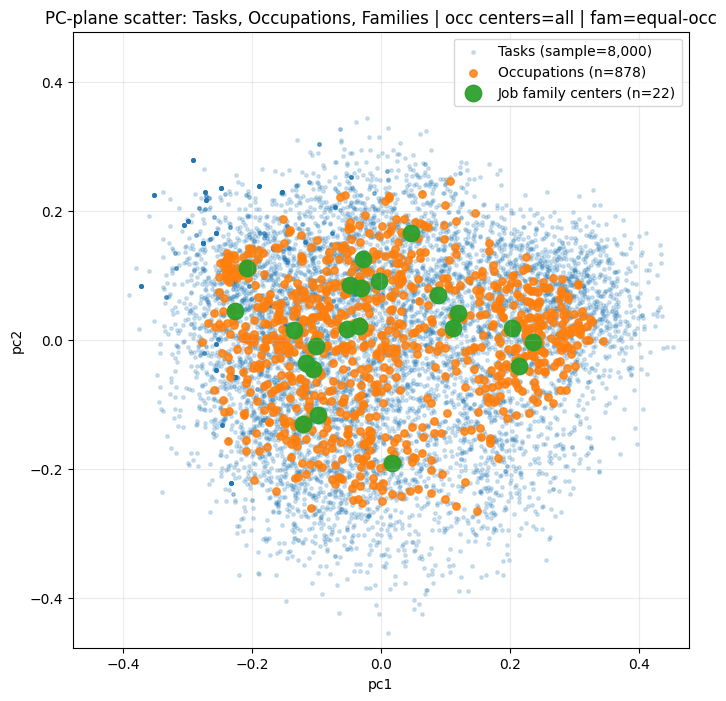

Scatter klart.
  tasks: 17,606 (plotted: 8,000)
  occ:   878
  fam:   22

Key columns:
df_occ: ['onet_code', 'pc1', 'pc2', 'n_tasks_used', 'RT_sum_used', 'Job Family', 'Title', 'xi', 'r', 'chi', 'sector', 'zone', 'sector_zone']
df_fam: ['Job Family', 'pc1', 'pc2', 'n_occ_used', 'xi', 'r', 'chi', 'sector', 'zone', 'sector_zone', 'xi_concentration_R']


In [9]:
# Cell 7: Build df_occ + df_fam from df_tasks (RT-weighted centers in KANON pc-plane)
# - KANON: pc1/pc2
# - OCC_CENTER_TASKS: "core" | "all" (core vs core+supp)
# - RT-weighted centers for df_occ (task mass = RT via RT_COL)
# - df_fam centers from df_occ (each occupation counts equally; independent of #tasks)
# - Job Family/Title mapping ALWAYS from ALL df_tasks
# - df_tasks only filled with missing xi/r/chi/sector/zone/sector_zone if absent

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------
# 0) Preconditions
# ----------------------------
if "df_tasks" not in globals() or df_tasks is None:
    raise RuntimeError("df_tasks saknas i globals().")

need_tasks = {"onet_code", "pc1", "pc2"}
miss = sorted(need_tasks - set(df_tasks.columns))
if miss:
    raise ValueError(f"df_tasks saknar kolumner: {miss}")

HAS_SECTOR_ZONE = ("sector_zone_labels" in globals()) and ("N_SECTORS" in globals()) and ("CHI_BINS" in globals())

# Global flags (lägg i parametercell vid behov)
OCC_CENTER_TASKS = str(globals().get("OCC_CENTER_TASKS", "all")).lower().strip()  # "all" | "core"
CORE_COL         = str(globals().get("CORE_COL", "is_core"))
RT_COL           = str(globals().get("RT_COL", "rt"))
SECTOR_ROTATION  = float(globals().get("SECTOR_ROTATION", 0.0))

if OCC_CENTER_TASKS not in {"all", "core"}:
    raise ValueError(f"OCC_CENTER_TASKS måste vara 'all' eller 'core', fick: {OCC_CENTER_TASKS!r}")

if RT_COL not in df_tasks.columns:
    raise ValueError(
        f"Saknar RT-kolumn {RT_COL!r} i df_tasks. "
        f"Sätt RT_COL till rätt kolumnnamn eller lägg till RT."
    )

# ----------------------------
# 1) Minimal task table (pc-plane) + RT + label maps (ALL tasks, alltid)
#    OBS: vi standardiserar "massa" till kolumnen RT i tasks0 (oavsett RT_COL)
# ----------------------------
tasks0 = df_tasks[["onet_code", "pc1", "pc2", RT_COL]].copy()

tasks0["pc1"] = pd.to_numeric(tasks0["pc1"], errors="coerce")
tasks0["pc2"] = pd.to_numeric(tasks0["pc2"], errors="coerce")
tasks0["RT"]  = pd.to_numeric(tasks0[RT_COL], errors="coerce")

tasks0 = tasks0.dropna(subset=["onet_code", "pc1", "pc2"])

# RT: NaN/inf/negativa -> 0 (massa kan inte vara <0)
tasks0["RT"] = tasks0["RT"].where(np.isfinite(tasks0["RT"]), 0.0)
tasks0.loc[tasks0["RT"] < 0, "RT"] = 0.0

# Job Family mapping (onet_code -> Job Family) från ALL df_tasks
jobfam_map = None
if "Job Family" in df_tasks.columns:
    jobfam_map = (
        df_tasks[["onet_code", "Job Family"]]
        .dropna(subset=["onet_code", "Job Family"])
        .drop_duplicates(subset=["onet_code"])
    )

# Title mapping (onet_code -> Title) från ALL df_tasks
title_map = None
if "Title" in df_tasks.columns:
    title_map = (
        df_tasks[["onet_code", "Title"]]
        .dropna(subset=["onet_code", "Title"])
        .drop_duplicates(subset=["onet_code"])
    )

# ----------------------------
# 2) Välj vilka tasks som används för att beräkna centra (yrke)
# ----------------------------
tasks_cent = tasks0
if OCC_CENTER_TASKS == "core":
    if CORE_COL not in df_tasks.columns:
        raise ValueError(f"OCC_CENTER_TASKS='core' men df_tasks saknar kolumnen {CORE_COL!r}")

    core_ser = df_tasks.loc[tasks0.index, CORE_COL]  # align till tasks0-rader
    core_m = pd.to_numeric(core_ser, errors="coerce").fillna(0).astype(int) > 0
    tasks_cent = tasks0.loc[core_m].copy()

print(f"centers from: {OCC_CENTER_TASKS} | tasks used: {len(tasks_cent):,} / {len(tasks0):,}")

# ----------------------------
# 3) Helpers: RT-weighted means in pc-plane + polar + sector/zone
# ----------------------------
TAU = 2 * np.pi

def _weighted_center_pc(df: pd.DataFrame, gcol: str, wcol: str = "RT") -> pd.DataFrame:
    """
    RT-weighted center in pc-plane (task mass = RT).
    - If total weight in group == 0: fallback to unweighted mean (warns).
    Returns: [gcol, pc1, pc2, n_tasks_used, RT_sum_used]
    """
    need = {gcol, "pc1", "pc2", wcol}
    miss = sorted(need - set(df.columns))
    if miss:
        raise ValueError(f"_weighted_center_pc: saknar kolumner: {miss}")

    d = df[[gcol, "pc1", "pc2", wcol]].copy()
    d = d.dropna(subset=[gcol, "pc1", "pc2"])
    if d.empty:
        return pd.DataFrame(columns=[gcol, "pc1", "pc2", "n_tasks_used", "RT_sum_used"])

    d["pc1"] = pd.to_numeric(d["pc1"], errors="coerce")
    d["pc2"] = pd.to_numeric(d["pc2"], errors="coerce")
    d[wcol]  = pd.to_numeric(d[wcol], errors="coerce").fillna(0.0)

    d = d.dropna(subset=["pc1", "pc2"])
    
    w = d[wcol].to_numpy(dtype=float, copy=True)
    w[~np.isfinite(w)] = 0.0

    w[w < 0] = 0.0
    d[wcol] = w

    # weighted sums via vectorisation
    d["_wpc1"] = d["pc1"] * d[wcol]
    d["_wpc2"] = d["pc2"] * d[wcol]

    g = d.groupby(gcol, dropna=True)

    out = g.agg(
        RT_sum_used=(wcol, "sum"),
        n_tasks_used=(wcol, "size"),
        _sx=("_wpc1", "sum"),
        _sy=("_wpc2", "sum"),
        _mx=("pc1", "mean"),
        _my=("pc2", "mean"),
    ).reset_index()

    den = out["RT_sum_used"].to_numpy(float)
    use_w = den > 0

    if np.any(~use_w):
        bad = out.loc[~use_w, [gcol, "n_tasks_used"]]
        examples = ", ".join(
            f"{row[gcol]} (n_tasks={int(row['n_tasks_used'])})"
            for _, row in bad.head(8).iterrows()
        )
        more = "" if len(bad) <= 8 else f" … +{len(bad)-8} fler"
        warnings.warn(
            f"[weighted_center_pc] RT_sum_used == 0 → fallback till oviktat medel "
            f"för {len(bad)} grupper. Exempel: {examples}{more}",
            RuntimeWarning,
            stacklevel=2,
        )

    out["pc1"] = np.where(use_w, out["_sx"].to_numpy(float) / den, out["_mx"].to_numpy(float))
    out["pc2"] = np.where(use_w, out["_sy"].to_numpy(float) / den, out["_my"].to_numpy(float))

    return out[[gcol, "pc1", "pc2", "n_tasks_used", "RT_sum_used"]]

def _attach_polar_from_pc(df: pd.DataFrame, xcol="pc1", ycol="pc2", *, rot: float = 0.0):
    x = pd.to_numeric(df[xcol], errors="coerce").to_numpy(float)
    y = pd.to_numeric(df[ycol], errors="coerce").to_numpy(float)

    r  = np.hypot(x, y)
    xi = (np.arctan2(y, x) + float(rot)) % TAU

    df["xi"] = xi
    df["r"]  = r

    if "R_SCALE" in globals() and globals()["R_SCALE"] is not None:
        df["chi"] = globals()["R_SCALE"].to_chi(r)
    else:
        df["chi"] = np.nan

def _attach_sector_zone(df: pd.DataFrame):
    if not HAS_SECTOR_ZONE:
        df["sector"] = pd.Series([pd.NA] * len(df), index=df.index, dtype="Int64")
        df["zone"] = pd.Series(["NA"] * len(df), index=df.index, dtype="string")
        df["sector_zone"] = pd.Series(["NA-NA"] * len(df), index=df.index, dtype="string")
        return

    xi_  = pd.to_numeric(df["xi"],  errors="coerce").to_numpy(float)
    chi_ = pd.to_numeric(df["chi"], errors="coerce").to_numpy(float)

    sec, zon, _ = sector_zone_labels(xi_, chi_, int(N_SECTORS), list(CHI_BINS))

    df["sector"] = pd.Series(sec, index=df.index).astype("Int64")
    df["zone"]   = pd.Series(zon, index=df.index).astype("string").fillna("NA")

    sector_str = df["sector"].map(lambda x: f"{int(x):02d}" if pd.notna(x) else "NA")
    df["sector_zone"] = sector_str + "-" + df["zone"].astype(str)


# ----------------------------
# 4) df_occ: occupation centers (RT-weighted in pc-plane) från tasks_cent
# ----------------------------
df_occ = _weighted_center_pc(tasks_cent, "onet_code", wcol="RT")

_attach_polar_from_pc(df_occ, rot=SECTOR_ROTATION)

# Attach labels (ALL-task mapping; påverkar inte geometri)
if jobfam_map is not None and not jobfam_map.empty:
    df_occ = df_occ.merge(jobfam_map, on="onet_code", how="left")
else:
    df_occ["Job Family"] = pd.NA
    print("ℹ️  'Job Family' saknas i df_tasks → df_occ får Job Family=NA.")

if title_map is not None and not title_map.empty:
    df_occ = df_occ.merge(title_map, on="onet_code", how="left")
else:
    df_occ["Title"] = pd.NA

_attach_sector_zone(df_occ)

globals()["df_occ"] = df_occ

# ----------------------------
# 5) Ensure df_tasks has xi/r/chi + sector/zone/sector_zone (only if missing)
# ----------------------------
need_polar = [c for c in ["xi", "r", "chi"] if c not in df_tasks.columns]
if need_polar:
    _attach_polar_from_pc(df_tasks, xcol="pc1", ycol="pc2", rot=SECTOR_ROTATION)

need_sz = [c for c in ["sector", "zone", "sector_zone"] if c not in df_tasks.columns]
if need_sz:
    _attach_sector_zone(df_tasks)

# ----------------------------
# 6) df_fam: family centers from OCCUPATIONS (each occupation counts equally)
#    + ensure n_occ_used exists (downstream expects a family-size column)
# ----------------------------
occ_f = df_occ.dropna(subset=["Job Family", "pc1", "pc2"]).copy()
occ_f["pc1"] = pd.to_numeric(occ_f["pc1"], errors="coerce")
occ_f["pc2"] = pd.to_numeric(occ_f["pc2"], errors="coerce")
occ_f = occ_f.dropna(subset=["pc1", "pc2"])

df_fam = (
    occ_f.groupby("Job Family", dropna=True, as_index=False)
         .agg(
             pc1=("pc1", "mean"),
             pc2=("pc2", "mean"),
             n_occ_used=("onet_code", "nunique"),
         )
)

# Warn on tiny families (optional but useful)
tiny = df_fam.loc[df_fam["n_occ_used"] < 3, ["Job Family", "n_occ_used"]]
if len(tiny):
    examples = ", ".join(f"{r['Job Family']} (n_occ={int(r['n_occ_used'])})" for _, r in tiny.head(8).iterrows())
    more = "" if len(tiny) <= 8 else f" … +{len(tiny)-8} fler"
    warnings.warn(
        f"[df_fam] Vissa familjer har få occupations (instabila centra): {examples}{more}",
        RuntimeWarning,
        stacklevel=2,
    )

_attach_polar_from_pc(df_fam, rot=SECTOR_ROTATION)
_attach_sector_zone(df_fam)

def _xi_concentration(th: pd.Series) -> float:
    th = pd.to_numeric(th, errors="coerce").to_numpy(float)
    th = th[np.isfinite(th)]
    if th.size == 0:
        return float("nan")
    return float(np.sqrt((np.cos(th).mean())**2 + (np.sin(th).mean())**2))

xiR = (
    occ_f.groupby("Job Family", dropna=True)["xi"]
         .apply(_xi_concentration)
         .rename("xi_concentration_R")
         .reset_index()
)

df_fam = df_fam.merge(xiR, on="Job Family", how="left")

globals()["df_fam"] = df_fam

# ----------------------------
# 7) Plot (pc-plane only)
# ----------------------------
TASK_SAMPLE = int(globals().get("TASK_SAMPLE", 8000))

tasks_plot_src = tasks0[["pc1", "pc2"]].copy()
tasks_plot = tasks_plot_src.sample(n=TASK_SAMPLE, random_state=42) if len(tasks_plot_src) > TASK_SAMPLE else tasks_plot_src

occ_plot_df = df_occ[["pc1", "pc2"]].copy().dropna(subset=["pc1", "pc2"])
fam_plot_df = df_fam[["pc1", "pc2"]].copy().dropna(subset=["pc1", "pc2"])

fig, ax = plt.subplots(figsize=(10, 8))

ax.scatter(tasks_plot["pc1"], tasks_plot["pc2"], s=6, alpha=0.20,
           label=f"Tasks (sample={len(tasks_plot):,})")

ax.scatter(occ_plot_df["pc1"], occ_plot_df["pc2"], s=28, alpha=0.85,
           label=f"Occupations (n={len(occ_plot_df):,})")

if len(fam_plot_df):
    ax.scatter(fam_plot_df["pc1"], fam_plot_df["pc2"], s=140, alpha=0.95, linewidths=1.0,
               label=f"Job family centers (n={len(fam_plot_df):,})")

ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("pc1")
ax.set_ylabel("pc2")
ax.set_title(f"PC-plane scatter: Tasks, Occupations, Families | occ centers={OCC_CENTER_TASKS} | fam=equal-occ")
ax.grid(True, alpha=0.25)
ax.legend(loc="best")

x_all = np.concatenate([
    tasks_plot["pc1"].to_numpy(),
    occ_plot_df["pc1"].to_numpy(),
    fam_plot_df["pc1"].to_numpy() if len(fam_plot_df) else np.array([], float),
])
y_all = np.concatenate([
    tasks_plot["pc2"].to_numpy(),
    occ_plot_df["pc2"].to_numpy(),
    fam_plot_df["pc2"].to_numpy() if len(fam_plot_df) else np.array([], float),
])
m = np.nanmax(np.abs(np.concatenate([x_all, y_all]))) if (x_all.size or y_all.size) else np.nan
if np.isfinite(m) and m > 0:
    pad = 0.05 * m
    ax.set_xlim(-m - pad, m + pad)
    ax.set_ylim(-m - pad, m + pad)

plt.show()

# ----------------------------
# 8) Summary prints
# ----------------------------
print("Scatter klart.")
print("  tasks:", f"{len(tasks0):,}", "(plotted:", f"{len(tasks_plot):,})")
print("  occ:  ", f"{len(df_occ):,}")
print("  fam:  ", f"{len(df_fam):,}")
n_na = int(df_occ["Job Family"].isna().sum())
if n_na:
    print(f"⚠️  df_occ saknar Job Family för {n_na:,} occupations (påverkar df_fam/legend).")

print("\nKey columns:")
print("df_occ:", [c for c in ["onet_code","pc1","pc2","n_tasks_used","RT_sum_used","Job Family","Title","xi","r","chi","sector","zone","sector_zone"] if c in df_occ.columns])
print("df_fam:", [c for c in ["Job Family","pc1","pc2","n_occ_used","xi","r","chi","sector","zone","sector_zone","xi_concentration_R"] if c in df_fam.columns])


In [10]:
# Cell 8: Align by xi only (rotation + optional reflection), apply to pc1/pc2
# - Fit görs enbart på vinkel (xi) mot referensfilen i data/
# - Hanterar spegling explicit (det(R)=+1 eller -1)
# - Ingen translation, ingen skalning: endast ortogonal 2x2 på pc1/pc2
# - Synkar xi/r/chi från pc1/pc2 efter transform (chi via R_SCALE om den finns)
# - (Valfritt) recompute sector/zone om sector_zone_labels finns
# - Muterar INTE kolumnschema (bara pc1/pc2 + härledda xi/r/chi/sector/zone)

import numpy as np
import pandas as pd
from pathlib import Path

# ----------------------------
# 0) Preconditions
# ----------------------------
for name in ["df_tasks", "df_occ", "df_fam"]:
    if name not in globals() or globals()[name] is None:
        raise RuntimeError(f"{name} saknas efter Cell 5.")

for name, need in [
    ("df_tasks", {"pc1", "pc2"}),
    ("df_occ",   {"onet_code", "pc1", "pc2", "xi"}),
    ("df_fam",   {"pc1", "pc2"}),
]:
    miss = sorted(need - set(globals()[name].columns))
    if miss:
        raise ValueError(f"{name} saknar kolumner: {miss}")

SECTOR_ROTATION = float(globals().get("SECTOR_ROTATION", 0.0))
HAS_SECTOR_ZONE = ("sector_zone_labels" in globals()) and ("N_SECTORS" in globals()) and ("CHI_BINS" in globals())

REF_OCC_CSV = RP.project_root / "data" / "procrustes_ref_occupation_embeddings_polar_scaled.csv"

TAU = 2 * np.pi

# ----------------------------
# 1) Helpers
# ----------------------------
def _wrap_pi(a: np.ndarray) -> np.ndarray:
    """Map angle diffs to (-pi, pi]."""
    return (a + np.pi) % (2 * np.pi) - np.pi

def _mean_angle(a: np.ndarray, w: np.ndarray | None = None) -> float:
    """Circular mean angle of a (radians)."""
    a = np.asarray(a, float)
    m = np.isfinite(a)
    if w is None:
        a = a[m]
        if a.size == 0:
            return float("nan")
        return float(np.arctan2(np.sin(a).mean(), np.cos(a).mean()))
    w = np.asarray(w, float)
    mw = m & np.isfinite(w) & (w > 0)
    a = a[mw]; w = w[mw]
    if a.size == 0:
        return float("nan")
    s = np.sum(w)
    if not np.isfinite(s) or s <= 0:
        return float("nan")
    return float(np.arctan2(np.sum(w*np.sin(a))/s, np.sum(w*np.cos(a))/s))

def _circ_rmse(err: np.ndarray, w: np.ndarray | None = None) -> float:
    """RMSE of angular error (already wrapped to (-pi,pi])."""
    e = np.asarray(err, float)
    m = np.isfinite(e)
    if w is None:
        e = e[m]
        return float(np.sqrt(np.mean(e*e))) if e.size else float("nan")
    w = np.asarray(w, float)
    mw = m & np.isfinite(w) & (w > 0)
    e = e[mw]; w = w[mw]
    if e.size == 0:
        return float("nan")
    s = np.sum(w)
    if not np.isfinite(s) or s <= 0:
        return float("nan")
    return float(np.sqrt(np.sum(w*(e*e)) / s))

def _R_from_delta(delta: float, reflect: bool) -> np.ndarray:
    """
    Orto-matris för:
      - reflect=False:  (x,y) -> R_delta @ (x,y)  (ren rotation, det=+1)
      - reflect=True:   (x,y) -> R_delta @ (x,-y) (spegling i x-axeln + rotation, det=-1)
    """
    c, s = float(np.cos(delta)), float(np.sin(delta))
    Rrot = np.array([[c, -s],
                     [s,  c]], dtype=float)
    if not reflect:
        return Rrot
    M = np.array([[1.0, 0.0],
                  [0.0, -1.0]], dtype=float)
    return Rrot @ M

def _apply_R_pc(df: pd.DataFrame, R: np.ndarray, xcol="pc1", ycol="pc2") -> None:
    x = pd.to_numeric(df[xcol], errors="coerce").to_numpy(float)
    y = pd.to_numeric(df[ycol], errors="coerce").to_numpy(float)
    XY = np.column_stack([x, y])
    ok = np.isfinite(XY).all(axis=1)
    if not np.any(ok):
        return
    XY2 = XY.copy()
    XY2[ok] = XY[ok] @ R.T  # (N,2) @ (2,2)
    df[xcol] = XY2[:, 0]
    df[ycol] = XY2[:, 1]

def _sync_polar_from_pc(df: pd.DataFrame) -> None:
    x = pd.to_numeric(df["pc1"], errors="coerce").to_numpy(float)
    y = pd.to_numeric(df["pc2"], errors="coerce").to_numpy(float)
    r  = np.hypot(x, y)
    xi = (np.arctan2(y, x) + float(SECTOR_ROTATION)) % TAU
    df["r"]  = r
    df["xi"] = xi
    if "R_SCALE" in globals() and globals()["R_SCALE"] is not None:
        df["chi"] = globals()["R_SCALE"].to_chi(r)
    else:
        df["chi"] = r  # fallback: metrisk radie

def _assign_sector_zone(df: pd.DataFrame) -> None:
    if not HAS_SECTOR_ZONE:
        return
    xi_  = pd.to_numeric(df["xi"],  errors="coerce").to_numpy(float)
    chi_ = pd.to_numeric(df["chi"], errors="coerce").to_numpy(float)
    sec, zon, _ = sector_zone_labels(xi_, chi_, int(N_SECTORS), list(CHI_BINS))
    df["sector"] = pd.Series(sec, index=df.index).astype("Int64")
    df["zone"]   = pd.Series(zon, index=df.index).astype("string").fillna("NA")
    df["sector_zone"] = (
        df["sector"].map(lambda x: f"{int(x):02d}" if pd.notna(x) else "NA")
        + "-"
        + df["zone"].astype(str)
    )

# ----------------------------
# 2) Read reference + build common set
# ----------------------------
ALIGN_META = {
    "aligned": False,
    "ref_file": str(REF_OCC_CSV),
    "n_common": 0,
    "delta": None,
    "reflect": None,
    "detR": None,
    "rmse_angle_before": None,
    "rmse_angle_after": None,
    "fit_space": "xi_only",
    "notes": None,
}

if not REF_OCC_CSV.exists():
    print(f"ℹ️ Ingen alignment – referensfil saknas: {REF_OCC_CSV}")
    globals()["ALIGN_META"] = ALIGN_META
else:
    ref_raw = pd.read_csv(REF_OCC_CSV)
    if "onet_code" not in ref_raw.columns:
        raise ValueError("Referensen saknar onet_code.")
    if "xi" not in ref_raw.columns:
        raise ValueError("Referensen saknar xi (krävs för xi-only alignment).")

    ref = ref_raw[["onet_code", "xi"]].copy()
    ref["xi_ref"] = pd.to_numeric(ref["xi"], errors="coerce")
    ref = ref.dropna(subset=["onet_code", "xi_ref"])[["onet_code", "xi_ref"]]

    cur = df_occ[["onet_code", "xi"]].copy()
    cur["xi_cur"] = pd.to_numeric(cur["xi"], errors="coerce")
    cur = cur.dropna(subset=["onet_code", "xi_cur"])[["onet_code", "xi_cur"]]

    common = cur.merge(ref, on="onet_code", how="inner")
    n_comm = int(len(common))
    ALIGN_META["n_common"] = n_comm

    if n_comm < 10:
        print(f"ℹ️ För få gemensamma yrken för alignment (n={n_comm}). Hoppar över.")
        ALIGN_META["notes"] = "too_few_common"
        globals()["ALIGN_META"] = ALIGN_META
    else:
        xi_cur = common["xi_cur"].to_numpy(float)
        xi_ref = common["xi_ref"].to_numpy(float)

        # Optional weighting (if you ever want it): use rt_sum_used if available; else unweighted.
        w = None

        # Model A: rotation only => xi_ref ≈ xi_cur + delta
        delta_A = _mean_angle(_wrap_pi(xi_ref - xi_cur), w=w)
        errA0   = _wrap_pi((xi_cur + delta_A) - xi_ref)
        rmseA   = _circ_rmse(errA0, w=w)

        # Model B: reflection + rotation => xi_ref ≈ (-xi_cur) + delta
        delta_B = _mean_angle(_wrap_pi(xi_ref + xi_cur), w=w)
        errB0   = _wrap_pi((-xi_cur + delta_B) - xi_ref)
        rmseB   = _circ_rmse(errB0, w=w)

        # Choose best
        reflect = bool(rmseB < rmseA)
        delta   = float(delta_B if reflect else delta_A)

        # Before/after RMSE (before: no transform)
        err_before = _wrap_pi(xi_cur - xi_ref)
        rmse_before = _circ_rmse(err_before, w=w)

        # Apply chosen model to pc-plane
        R = _R_from_delta(delta, reflect=reflect)
        detR = float(np.linalg.det(R))

        _apply_R_pc(df_tasks, R, "pc1", "pc2")
        _apply_R_pc(df_occ,   R, "pc1", "pc2")
        _apply_R_pc(df_fam,   R, "pc1", "pc2")

        # Recompute polar + sector/zone
        _sync_polar_from_pc(df_tasks); _sync_polar_from_pc(df_occ); _sync_polar_from_pc(df_fam)
        _assign_sector_zone(df_tasks); _assign_sector_zone(df_occ); _assign_sector_zone(df_fam)

        # After: compare xi from updated df_occ vs reference on same common set
        cur2 = df_occ[["onet_code", "xi"]].copy()
        cur2["xi_cur2"] = pd.to_numeric(cur2["xi"], errors="coerce")
        common2 = cur2.merge(ref, on="onet_code", how="inner").dropna(subset=["xi_cur2", "xi_ref"])
        err_after = _wrap_pi(common2["xi_cur2"].to_numpy(float) - common2["xi_ref"].to_numpy(float))
        rmse_after = _circ_rmse(err_after, w=None)

        ALIGN_META.update(
            aligned=True,
            delta=float(delta),
            reflect=reflect,
            detR=detR,
            rmse_angle_before=float(rmse_before),
            rmse_angle_after=float(rmse_after),
        )

        print(
            f"✅ Xi-align mot {Path(REF_OCC_CSV).name} | common={n_comm} | "
            f"reflect={reflect} | det(R)={detR:+.3f} | "
            f"RMSE(angle) {rmse_before:.6f} → {rmse_after:.6f} | delta={delta:.6f} rad"
        )

        globals()["ALIGN_META"] = ALIGN_META


✅ Xi-align mot procrustes_ref_occupation_embeddings_polar_scaled.csv | common=877 | reflect=False | det(R)=+1.000 | RMSE(angle) 3.015604 → 0.187640 | delta=-3.052255 rad


In [11]:
# Cell 9: Export – preserve ALL columns (no loss), new infra/RP
# - Skriver ut df_tasks/df_occ/df_fam med alla befintliga kolumner intakta
# - Säkrar att nyckelkolumner finns och ligger först i filen (resten följer efter)
# - Använder nya RP.mkpath + RP.exports (CURRENT RUN)
# - Ingen koordinatmutation här

import time
from pathlib import Path
import pandas as pd
from infra import RP, write_csv

t0 = time.perf_counter()

def _export_fp(stem: str, suffix: str = ".csv") -> Path:
    # Ny infra: skapa skrivpath i current run, under exports/
    suf = suffix if suffix.startswith(".") else f".{suffix}"
    return RP.mkpath("exports", f"{stem}{suf}")

def _export_preserve_all(df: pd.DataFrame, key_cols: list[str], fp: Path) -> pd.DataFrame:
    out = df.copy()

    # ensure keys exist
    for c in key_cols:
        if c not in out.columns:
            out[c] = pd.NA

    # order: keys first, then all other existing columns (in original order)
    rest = [c for c in out.columns if c not in key_cols]
    out = out[key_cols + rest]

    write_csv(fp, out, index=False)
    return out

# ----------------------------
# Tasks
# ----------------------------
TASK_KEYS = [
    "onet_code",
    "Task ID", "Task", "Task Type", "is_core",
    "rt", "rle_mean",
    "Title", "Job Family",
    "pc1", "pc2",
    "xi", "r", "chi",
    "sector", "zone", "sector_zone",
]
TASK_CSV = _export_fp("task_embeddings_polar_scaled", ".csv")
df_tasks_out = _export_preserve_all(df_tasks, TASK_KEYS, TASK_CSV)

# ----------------------------
# Occupations
# ----------------------------
OCC_KEYS = [
    "onet_code",
    "Title", "Job Family",
    "pc1", "pc2",
    "xi", "r", "chi",
    "sector", "zone", "sector_zone",
]
OCC_CSV = _export_fp("occupation_embeddings_polar_scaled", ".csv")
df_occ_out = _export_preserve_all(df_occ, OCC_KEYS, OCC_CSV)

# ----------------------------
# Families
# ----------------------------
FAM_KEYS = [
    "Job Family",
    # OBS: nya pipeline använder typiskt n_tasks_used + rt_sum_used (inte "n")
    "n_tasks_used", "rt_sum_used",
    "pc1", "pc2",
    "xi", "r", "chi",
    "sector", "zone", "sector_zone",
    "xi_concentration_R",
]
FAM_CSV = _export_fp("job_family_centers_polar_scaled", ".csv")
df_fam_out = _export_preserve_all(df_fam, FAM_KEYS, FAM_CSV)

t1 = time.perf_counter()
print(f"✅ Tasks sparade:        {len(df_tasks_out):,} → {TASK_CSV.name}")
print(f"✅ Yrken sparade:        {len(df_occ_out):,} → {OCC_CSV.name}")
print(f"✅ Job families sparade: {len(df_fam_out):,} → {FAM_CSV.name}")
print(f"📁 Exports-dir (run):    {RP.exports}")
print(f"⏱️  Exportcell: {t1 - t0:.2f}s")


✅ Tasks sparade:        17,606 → task_embeddings_polar_scaled.csv
✅ Yrken sparade:        878 → occupation_embeddings_polar_scaled.csv
✅ Job families sparade: 22 → job_family_centers_polar_scaled.csv
📁 Exports-dir (run):    /home/joc/code/geometry-of-work/out/runs/embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1/exports
⏱️  Exportcell: 0.11s


In [12]:
# Cell 10: Embedding quality — compact print + aggregated exports (new infra/RP)
# -----------------------------------------------------------------------------
# Changes vs v1:
#   - Uses new infra RP.mkpath("exports", ...) instead of RP.export_fp(...)
#   - Imports RP from infra; no globals()-check for RP
#   - Exports live under current run's exports/ (RP.exports)
#   - Keeps filenames human-readable and stable
# -----------------------------------------------------------------------------

import json
import numpy as np
import pandas as pd
from pathlib import Path
from infra import RP, write_csv

# ----------------------------
# 0) Preconditions
# ----------------------------
req_tasks = {"onet_code", "pc1", "pc2", "rt"}
req_occ   = {"onet_code", "pc1", "pc2", "Job Family", "Title"}
req_fam   = {"Job Family", "pc1", "pc2", "xi_concentration_R", "n_occ_used"}

miss = sorted(req_tasks - set(df_tasks.columns))
if miss: raise ValueError(f"df_tasks saknar kolumner: {miss}")
miss = sorted(req_occ - set(df_occ.columns))
if miss: raise ValueError(f"df_occ saknar kolumner: {miss}")
miss = sorted(req_fam - set(df_fam.columns))
if miss: raise ValueError(f"df_fam saknar kolumner: {miss}")

# ----------------------------
# 1) Helpers
# ----------------------------
def _as_str(s):
    return s.astype(str).str.strip()

def _safe_arr(x):
    x = pd.to_numeric(pd.Series(x), errors="coerce").to_numpy(float)
    return x[np.isfinite(x)]

def _q(x, qs=(0.1, 0.5, 0.9)):
    a = _safe_arr(x)
    if a.size == 0:
        return {f"q{int(100*q)}": np.nan for q in qs}
    out = np.quantile(a, qs)
    return {f"q{int(100*q)}": float(v) for q, v in zip(qs, out)}

def _fmt(x, nd=3):
    try:
        if x is None or (isinstance(x, float) and np.isnan(x)):
            return "NA"
        return f"{float(x):.{nd}f}"
    except Exception:
        return str(x)

def _export_fp(stem: str, suffix: str) -> Path:
    suf = suffix if suffix.startswith(".") else f".{suffix}"
    return RP.mkpath("exports", f"{stem}{suf}")

def _export_csv(df: pd.DataFrame, stem: str) -> Path:
    fp = _export_fp(stem, ".csv")
    write_csv(fp, df, index=False)
    return fp

def _export_json(obj, stem: str) -> Path:
    fp = _export_fp(stem, ".json")
    fp.write_text(json.dumps(obj, ensure_ascii=False, indent=2), encoding="utf-8")
    return fp

# ----------------------------
# 2) Prepare local numeric views (NO mutation of original frames)
# ----------------------------
t = df_tasks[list(req_tasks)].copy()
t["onet_code"] = _as_str(t["onet_code"])
t["pc1"] = pd.to_numeric(t["pc1"], errors="coerce")
t["pc2"] = pd.to_numeric(t["pc2"], errors="coerce")
t["rt"]  = pd.to_numeric(t["rt"],  errors="coerce").fillna(0.0).clip(lower=0.0)
t = t.dropna(subset=["onet_code", "pc1", "pc2"])

o = df_occ[list(req_occ)].copy()
o["onet_code"] = _as_str(o["onet_code"])
o["pc1"] = pd.to_numeric(o["pc1"], errors="coerce")
o["pc2"] = pd.to_numeric(o["pc2"], errors="coerce")
o["Job Family"] = o["Job Family"].astype(str).str.strip()
o = o.dropna(subset=["onet_code", "pc1", "pc2"])

f = df_fam[list(req_fam)].copy()
f["Job Family"] = f["Job Family"].astype(str).str.strip()
f["pc1"] = pd.to_numeric(f["pc1"], errors="coerce")
f["pc2"] = pd.to_numeric(f["pc2"], errors="coerce")
f["xi_concentration_R"] = pd.to_numeric(f["xi_concentration_R"], errors="coerce")
f["n"]   = pd.to_numeric(f["n_occ_used"], errors="coerce")
f = f.dropna(subset=["Job Family", "pc1", "pc2"])

# ----------------------------
# 3) A1: Within-occupation task compactness (dist tasks -> occ center)
# ----------------------------
m = t.merge(
    o[["onet_code", "pc1", "pc2"]].rename(columns={"pc1": "occ_pc1", "pc2": "occ_pc2"}),
    on="onet_code",
    how="inner",
)

dx = (m["pc1"].to_numpy(float) - m["occ_pc1"].to_numpy(float))
dy = (m["pc2"].to_numpy(float) - m["occ_pc2"].to_numpy(float))
m["_dist"] = np.sqrt(dx*dx + dy*dy)
m["_w"]    = m["rt"].to_numpy(float)
m["_wd"]   = m["_w"] * m["_dist"]

A1_unw = (
    m.groupby("onet_code", dropna=True)["_dist"]
     .agg(n_tasks_used="size",
          within_occupation_task_spread__mean_dist_to_occ_center="mean",
          within_occupation_task_spread__median_dist_to_occ_center="median")
     .reset_index()
)

A1_w = (
    m.groupby("onet_code", dropna=True)
     .agg(_w_sum=("_w", "sum"),
          _wd_sum=("_wd", "sum"),
          _dist_mean_fallback=("_dist", "mean"))
     .reset_index()
)
A1_w["within_occupation_task_spread__rt_weighted_mean_dist_to_occ_center"] = np.where(
    A1_w["_w_sum"].to_numpy(float) > 0,
    A1_w["_wd_sum"].to_numpy(float) / A1_w["_w_sum"].to_numpy(float),
    A1_w["_dist_mean_fallback"].to_numpy(float),
)

A1 = A1_unw.merge(
    A1_w[["onet_code", "within_occupation_task_spread__rt_weighted_mean_dist_to_occ_center"]],
    on="onet_code", how="left"
)

A1 = A1.merge(
    o[["onet_code", "Title", "Job Family"]].rename(columns={"Title": "occupation_title", "Job Family": "job_family"}),
    on="onet_code", how="left"
).rename(columns={"onet_code": "occupation_id_onet"})

# ----------------------------
# 4) B1: Between-occupation separation (mean inter-occ dist / mean within-occ spread)
# ----------------------------
occ_xy = o[["pc1", "pc2"]].to_numpy(float)
occ_ok = np.isfinite(occ_xy).all(axis=1)
occ_xy = occ_xy[occ_ok]
n_occ_used = int(occ_xy.shape[0])

if n_occ_used >= 2:
    G = occ_xy @ occ_xy.T
    s2 = np.sum(occ_xy * occ_xy, axis=1)
    d2 = (s2[:, None] + s2[None, :] - 2.0 * G)
    d2[d2 < 0] = 0.0
    iu = np.triu_indices(n_occ_used, k=1)
    inter_dist = np.sqrt(d2[iu])
    mean_inter_occ_dist = float(np.nanmean(inter_dist))
else:
    mean_inter_occ_dist = float("nan")

mean_within_occ_spread = float(np.nanmean(A1["within_occupation_task_spread__mean_dist_to_occ_center"].to_numpy(float)))
separation_index__inter_over_intra = (
    mean_inter_occ_dist / mean_within_occ_spread
    if np.isfinite(mean_inter_occ_dist) and np.isfinite(mean_within_occ_spread) and mean_within_occ_spread > 0
    else float("nan")
)

# ----------------------------
# 5) B2: Nearest-neighbor sanity (kNN same-family share)
# ----------------------------
K_NEIGH = 10
occ_ids = o.loc[occ_ok, "onet_code"].to_numpy()
occ_fam = o.loc[occ_ok, "Job Family"].to_numpy(object)

def _nn_same_family_rate(X, fam, k=10):
    X = np.asarray(X, float)
    fam = np.asarray(fam, object)
    n = X.shape[0]
    if n < 3:
        return np.full(n, np.nan), np.nan, np.nan

    G = X @ X.T
    s = np.sum(X * X, axis=1)
    d2 = (s[:, None] + s[None, :] - 2.0 * G)
    d2[d2 < 0] = 0.0
    np.fill_diagonal(d2, np.inf)

    kk = int(min(max(1, k), n - 1))
    nn_idx = np.argpartition(d2, kth=kk-1, axis=1)[:, :kk]

    rates = np.full(n, np.nan, dtype=float)
    for i in range(n):
        fi = fam[i]
        if fi is None or (isinstance(fi, float) and np.isnan(fi)) or str(fi) == "nan":
            continue
        rates[i] = float(np.mean(fam[nn_idx[i]] == fi))
    return rates, float(np.nanmean(rates)), float(np.nanmedian(rates))

B2_rates, B2_mean, B2_median = _nn_same_family_rate(occ_xy, occ_fam, k=K_NEIGH)

B2 = pd.DataFrame({
    "occupation_id_onet": occ_ids.astype(str),
    "job_family": occ_fam,
    f"nearest_neighbor_sanity__share_of_{K_NEIGH}_nearest_occupations_in_same_job_family": B2_rates,
})

df_occ_quality = (
    A1.merge(
        B2[["occupation_id_onet", f"nearest_neighbor_sanity__share_of_{K_NEIGH}_nearest_occupations_in_same_job_family"]],
        on="occupation_id_onet",
        how="left"
    )
)

# ----------------------------
# 6) C1: Family compactness (occ -> family center) + C2: directionality
# ----------------------------
fam_cent = f.set_index("Job Family")[["pc1", "pc2"]]

oo = o.dropna(subset=["Job Family"]).copy()
oo["Job Family"] = oo["Job Family"].astype(str).str.strip()
oo = oo[oo["Job Family"].isin(fam_cent.index)]

dx = oo["pc1"].to_numpy(float) - fam_cent.loc[oo["Job Family"], "pc1"].to_numpy(float)
dy = oo["pc2"].to_numpy(float) - fam_cent.loc[oo["Job Family"], "pc2"].to_numpy(float)
oo["_dist_to_fam_center"] = np.sqrt(dx*dx + dy*dy)

C1 = (
    oo.groupby("Job Family", dropna=True)["_dist_to_fam_center"]
      .agg(
          within_family_occupation_spread__mean_dist_to_family_center="mean",
          within_family_occupation_spread__median_dist_to_family_center="median",
          n_occupations_in_family_used="count",
      )
      .reset_index()
      .rename(columns={"Job Family": "job_family"})
)

df_family_quality = (
    C1.merge(
        f.rename(columns={"Job Family": "job_family", "n": "n_occupations_in_family_total"})[
            ["job_family", "n_occupations_in_family_total", "xi_concentration_R"]
        ],
        on="job_family",
        how="left"
    )
    .rename(columns={"xi_concentration_R": "family_directionality__xi_concentration_R"})
)

mean_family_spread = float(np.nanmean(df_family_quality["within_family_occupation_spread__mean_dist_to_family_center"].to_numpy(float)))
mean_xi_conc = float(np.nanmean(df_family_quality["family_directionality__xi_concentration_R"].to_numpy(float)))
share_xi_ge_07 = float(np.nanmean((df_family_quality["family_directionality__xi_concentration_R"].to_numpy(float) >= 0.7).astype(float)))

# ----------------------------
# 7) Aggregated overview (single-row) + meta (JSON)
# ----------------------------
q_within = _q(df_occ_quality["within_occupation_task_spread__mean_dist_to_occ_center"])
q_nn     = _q(df_occ_quality[f"nearest_neighbor_sanity__share_of_{K_NEIGH}_nearest_occupations_in_same_job_family"])
q_famrad = _q(df_family_quality["within_family_occupation_spread__mean_dist_to_family_center"])
q_xiconc = _q(df_family_quality["family_directionality__xi_concentration_R"])

df_overview = pd.DataFrame([{
    "n_tasks_used": int(len(t)),
    "n_occupations_used": int(len(df_occ_quality)),
    "n_job_families_used": int(len(df_family_quality)),

    "A_within_occ__mean_task_spread_mean_over_occupations": float(np.nanmean(df_occ_quality["within_occupation_task_spread__mean_dist_to_occ_center"].to_numpy(float))),
    "A_within_occ__mean_task_spread_q10": q_within["q10"],
    "A_within_occ__mean_task_spread_q50": q_within["q50"],
    "A_within_occ__mean_task_spread_q90": q_within["q90"],

    "B_between_occ__mean_inter_occupation_distance": mean_inter_occ_dist,
    "B_between_occ__separation_index_inter_over_intra": separation_index__inter_over_intra,

    f"B_neighbors__mean_share_of_{K_NEIGH}_nn_in_same_family": B2_mean,
    f"B_neighbors__median_share_of_{K_NEIGH}_nn_in_same_family": B2_median,
    "B_neighbors__same_family_share_q10": q_nn["q10"],
    "B_neighbors__same_family_share_q50": q_nn["q50"],
    "B_neighbors__same_family_share_q90": q_nn["q90"],

    "C_family__mean_family_spread_mean_over_families": mean_family_spread,
    "C_family__family_spread_q10": q_famrad["q10"],
    "C_family__family_spread_q50": q_famrad["q50"],
    "C_family__family_spread_q90": q_famrad["q90"],

    "C_family__mean_directionality_R_mean_over_families": mean_xi_conc,
    "C_family__directionality_R_q10": q_xiconc["q10"],
    "C_family__directionality_R_q50": q_xiconc["q50"],
    "C_family__directionality_R_q90": q_xiconc["q90"],
    "C_family__share_families_R_ge_0p7": share_xi_ge_07,
}])

meta = {
    "definitions": {
        "A_within_occ__task_compactness": "Distances from tasks (pc1,pc2) to occupation center (pc1,pc2). Lower means tasks cluster more tightly within an occupation.",
        "B_between_occ__separation_index_inter_over_intra": "Mean distance between occupation centers divided by mean within-occupation task spread.",
        "B_neighbors__knn_same_family_share": f"For each occupation, share of its {K_NEIGH} nearest occupations that are in the same Job Family.",
        "C_family__family_spread": "Distances from occupations to their Job Family center (pc1,pc2). Lower means the family is more compact.",
        "C_family__directionality_R": "Angular concentration in xi (R). Higher means stronger shared direction within family.",
    },
    "parameters": {"k_nearest_neighbors": int(K_NEIGH)},
    "counts": {
        "n_tasks_used": int(len(t)),
        "n_occupations_used": int(len(df_occ_quality)),
        "n_job_families_used": int(len(df_family_quality)),
    },
    "overview": df_overview.iloc[0].to_dict(),
}

# ----------------------------
# 8) Minimal print (compact)
# ----------------------------
print("\n=== Embedding quality (compact) ===")
print(f"Used: tasks={len(t):,} | occupations={len(df_occ_quality):,} | job families={len(df_family_quality):,}")
print(f"A) Within-occupation task spread (mean over occ): {_fmt(df_overview.loc[0, 'A_within_occ__mean_task_spread_mean_over_occupations'])} "
      f"[q10/q50/q90={_fmt(q_within['q10'])}/{_fmt(q_within['q50'])}/{_fmt(q_within['q90'])}]")
print(f"B) Separation index (inter / intra): {_fmt(separation_index__inter_over_intra)} "
      f"(mean inter-occ dist={_fmt(mean_inter_occ_dist)})")
print(f"B) kNN same-family share (k={K_NEIGH}): mean={_fmt(B2_mean)} "
      f"[q10/q50/q90={_fmt(q_nn['q10'])}/{_fmt(q_nn['q50'])}/{_fmt(q_nn['q90'])}]")
print(f"C) Family spread (mean over fam): {_fmt(mean_family_spread)} "
      f"[q10/q50/q90={_fmt(q_famrad['q10'])}/{_fmt(q_famrad['q50'])}/{_fmt(q_famrad['q90'])}]")
print(f"C) Family directionality R: mean={_fmt(mean_xi_conc)} | share(R>=0.7)={_fmt(share_xi_ge_07, nd=2)}")

# ----------------------------
# 9) Exports (few, readable) — new infra/RP
# ----------------------------
paths = {}
paths["overview_csv"]        = _export_csv(df_overview, "embedding_quality__overview")
paths["per_occupation_csv"]  = _export_csv(df_occ_quality, "embedding_quality__per_occupation")
paths["per_job_family_csv"]  = _export_csv(df_family_quality, "embedding_quality__per_job_family")
paths["meta_json"]           = _export_json(meta, "embedding_quality__meta")

globals()["EMB_QUALITY__per_occupation"] = df_occ_quality
globals()["EMB_QUALITY__per_job_family"] = df_family_quality
globals()["EMB_QUALITY__overview"] = df_overview
globals()["EMB_QUALITY__meta"] = meta
globals()["EMB_QUALITY__exports"] = paths

print("\n✅ Exported (current run exports/):")
print(f"📁 {RP.exports}")
for k, p in paths.items():
    print(f"  - {k}: {p.name}")



=== Embedding quality (compact) ===
Used: tasks=17,606 | occupations=878 | job families=22
A) Within-occupation task spread (mean over occ): 0.112 [q10/q50/q90=0.083/0.112/0.139]
B) Separation index (inter / intra): 2.155 (mean inter-occ dist=0.241)
B) kNN same-family share (k=10): mean=0.296 [q10/q50/q90=0.000/0.200/0.700]
C) Family spread (mean over fam): 0.078 [q10/q50/q90=0.049/0.078/0.093]
C) Family directionality R: mean=0.793 | share(R>=0.7)=0.68

✅ Exported (current run exports/):
📁 /home/joc/code/geometry-of-work/out/runs/embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1/exports
  - overview_csv: embedding_quality__overview.csv
  - per_occupation_csv: embedding_quality__per_occupation.csv
  - per_job_family_csv: embedding_quality__per_job_family.csv
  - meta_json: embedding_quality__meta.json


RUN_DIR = /home/joc/code/geometry-of-work/out/runs/embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1
SCALER_MODE = none, SCALER_FN = log


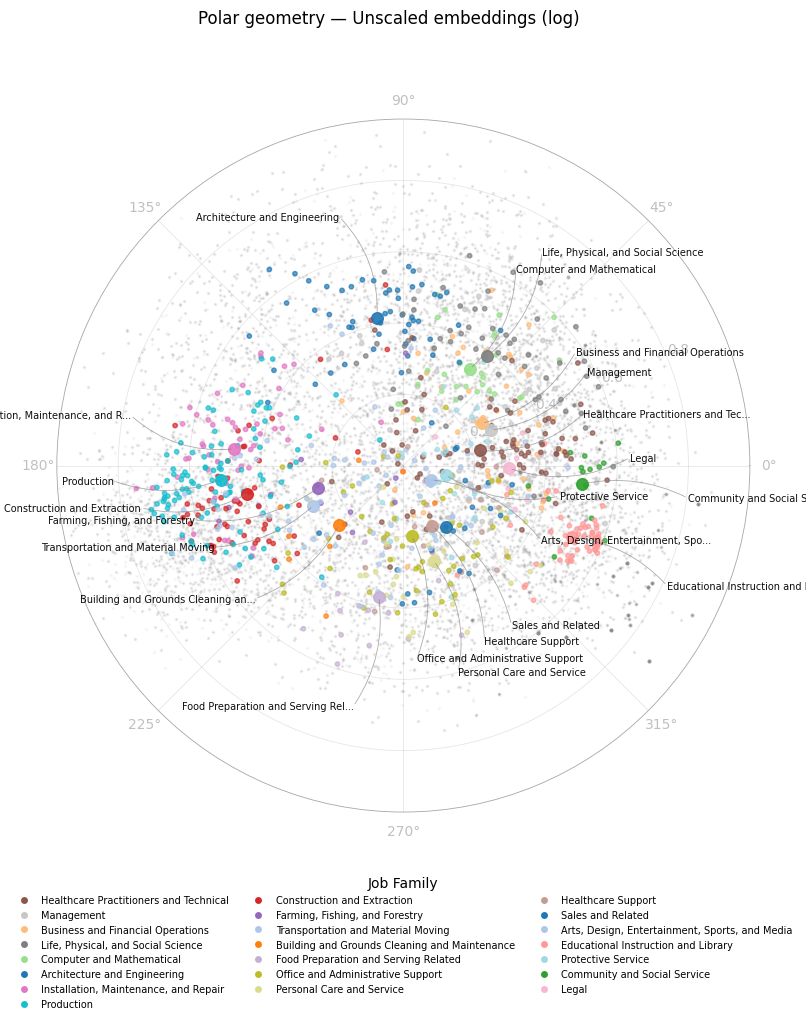

✅ Sparat figur: /home/joc/code/geometry-of-work/out/runs/embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1/figures/occupations_job_families_centers.png
✅ Sparat figur: /home/joc/code/geometry-of-work/out/runs/embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1/figures/occupations_job_families_centers.pdf


In [13]:
# Cell 12: Polär karta (uses in-memory df_tasks, df_occ, df_fam)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from plotutils import place_polar_labels_no_overlap_fast2

MAX_LABEL_LEN = 35
LABEL_SEED = 27

# ----------------------------
# 0) Use in-memory DataFrames (no file loading)
# ----------------------------
print("RUN_DIR =", RP.run_dir)
print(f"SCALER_MODE = {SCALER_MODE}, SCALER_FN = {SCALER_FN}")

# ----------------------------
# 1) Validate inputs
# ----------------------------
need_occ = {"xi", "chi", "Title", "onet_code", "Job Family", "pc1", "pc2"}
miss_occ = sorted(need_occ - set(df_occ.columns))
if miss_occ:
    raise ValueError(f"df_occ saknar kolumner: {miss_occ}")

need_fam = {"Job Family", "xi", "chi", "pc1", "pc2"}
miss_fam = sorted(need_fam - set(df_fam.columns))
if miss_fam:
    raise ValueError(f"df_fam saknar kolumner: {miss_fam}")

need_tasks = {"xi", "chi", "is_core"}
miss_tasks = sorted(need_tasks - set(df_tasks.columns))
if miss_tasks:
    raise ValueError(f"df_tasks saknar kolumner: {miss_tasks}")

# Lokala numeriska kopior (skriv inte tillbaka)
occ_xi = pd.to_numeric(df_occ["xi"], errors="coerce")
occ_chi = pd.to_numeric(df_occ["chi"], errors="coerce")

task_xi = pd.to_numeric(df_tasks["xi"], errors="coerce")
task_chi = pd.to_numeric(df_tasks["chi"], errors="coerce")

fam_xi = (pd.to_numeric(df_fam["xi"], errors="coerce") % (2 * np.pi))
fam_chi = pd.to_numeric(df_fam["chi"], errors="coerce")

r_max = float(np.nanmax(np.concatenate([occ_chi.to_numpy(), fam_chi.to_numpy()])))
if not np.isfinite(r_max) or r_max <= 0:
    raise RuntimeError("Kunde inte bestämma r_max från df_occ['chi'].")

# ----------------------------
# 2) Family colors (tab20 cycling)
# ----------------------------
unique_families = sorted(df_occ["Job Family"].dropna().unique())
family_to_color = {fam: i for i, fam in enumerate(unique_families)}
base_cmap = plt.colormaps.get("tab20")
cmap = [base_cmap(i % base_cmap.N) for i in range(max(1, len(unique_families)))]

def _fam_color(fam):
    if pd.notna(fam) and fam in family_to_color:
        return cmap[family_to_color[fam]]
    return (0.6, 0.6, 0.6)

colors = df_occ["Job Family"].map(_fam_color)

# ----------------------------
# 3) Plot
# ----------------------------
FIGSIZE = (12, 11)

fig, ax = plt.subplots(figsize=FIGSIZE, subplot_kw={"projection": "polar"})
ax.set_axisbelow(True)

# --- Axlar/periferi/skala – nedtonat ---
AX_GRAY = (0.65, 0.65, 0.65)

ax.grid(True, color=AX_GRAY, alpha=0.28, linewidth=0.6)
ax.spines["polar"].set_color(AX_GRAY)
ax.spines["polar"].set_linewidth(0.6)
ax.tick_params(axis="x", colors=AX_GRAY, length=3, width=0.6)
ax.tick_params(axis="y", colors=AX_GRAY, length=3, width=0.6)

for t in ax.get_xticklabels() + ax.get_yticklabels():
    t.set_color(AX_GRAY)
    t.set_alpha(0.7)

ax.yaxis.label.set_color(AX_GRAY)
ax.xaxis.label.set_color(AX_GRAY)

# --- Tasks: core/supp ---
task_mask = task_xi.notna() & task_chi.notna() & np.isfinite(task_xi) & np.isfinite(task_chi)
is_core = df_tasks["is_core"].fillna(False).astype(bool)
supp_mask = task_mask & ~is_core
core_mask = task_mask & is_core

SUPP_GRAY = (0.75, 0.75, 0.75)
CORE_GRAY = (0.55, 0.55, 0.55)

TASK_BASE_SIZE = 2
TASK_HALO_SIZE = 8
SUPP_BASE_ALPHA = 0.18
SUPP_HALO_ALPHA = 0.05
CORE_BASE_ALPHA = 0.28
CORE_HALO_ALPHA = 0.08

TASK_SAMPLE = 8000
if int(supp_mask.sum() + core_mask.sum()) > TASK_SAMPLE:
    idx = np.flatnonzero((supp_mask | core_mask).to_numpy())
    take = np.random.RandomState(42).choice(idx, size=TASK_SAMPLE, replace=False)
    take = pd.Index(df_tasks.index[take])
    supp_mask = supp_mask & df_tasks.index.isin(take)
    core_mask = core_mask & df_tasks.index.isin(take)

if supp_mask.any():
    ax.scatter(task_xi[supp_mask].to_numpy(), task_chi[supp_mask].to_numpy(),
               s=TASK_HALO_SIZE, alpha=SUPP_HALO_ALPHA, c=[SUPP_GRAY],
               linewidths=0, zorder=0.20, rasterized=True)
    ax.scatter(task_xi[supp_mask].to_numpy(), task_chi[supp_mask].to_numpy(),
               s=TASK_BASE_SIZE, alpha=SUPP_BASE_ALPHA, c=[SUPP_GRAY],
               linewidths=0, zorder=0.25, rasterized=True)

if core_mask.any():
    ax.scatter(task_xi[core_mask].to_numpy(), task_chi[core_mask].to_numpy(),
               s=TASK_HALO_SIZE, alpha=CORE_HALO_ALPHA, c=[CORE_GRAY],
               linewidths=0, zorder=0.28, rasterized=True)
    ax.scatter(task_xi[core_mask].to_numpy(), task_chi[core_mask].to_numpy(),
               s=TASK_BASE_SIZE, alpha=CORE_BASE_ALPHA, c=[CORE_GRAY],
               linewidths=0, zorder=0.30, rasterized=True)

# --- Occupations ---
occ_mask = occ_xi.notna() & occ_chi.notna() & np.isfinite(occ_xi) & np.isfinite(occ_chi)
ax.scatter(occ_xi[occ_mask].to_numpy(), occ_chi[occ_mask].to_numpy(),
           color=colors.loc[occ_mask].to_list(),
           s=10, alpha=0.7, zorder=1, rasterized=True)

# --- Family centers ---
fam_mask = fam_xi.notna() & fam_chi.notna() & np.isfinite(fam_xi) & np.isfinite(fam_chi)
theta_list, chi_list, label_list, legend_data = [], [], [], []

for i in np.flatnonzero(fam_mask.to_numpy()):
    fam = df_fam.iloc[i]["Job Family"]
    if pd.isna(fam) or fam not in family_to_color:
        continue

    theta = float(fam_xi.iloc[i])
    chi = float(fam_chi.iloc[i])
    if not np.isfinite(theta) or not np.isfinite(chi):
        continue

    LABEL_CUT = MAX_LABEL_LEN - 3
    label = fam[:LABEL_CUT] + "..." if len(fam) > MAX_LABEL_LEN else fam

    fam_color = _fam_color(fam)

    ax.scatter(theta, chi, s=70, color=fam_color, alpha=0.90, zorder=3)
    theta_list.append(theta)
    chi_list.append(chi)
    label_list.append(label)
    legend_data.append((theta, fam, fam_color))

# wrap-around för label-klustring
if len(theta_list) >= 2:
    th = np.array(theta_list, dtype=float)
    if (th.min() < np.deg2rad(8)) and (th.max() > (2 * np.pi - np.deg2rad(8))):
        th2 = th.copy()
        th2[th2 < np.deg2rad(8)] += 2 * np.pi
        theta_for_labels = th2.tolist()
    else:
        theta_for_labels = theta_list
else:
    theta_for_labels = theta_list

place_polar_labels_no_overlap_fast2(
    ax, theta_for_labels, chi_list, label_list,
    base_offset=0.30, fontsize=7, max_iter=60,
    step_r_px=3.0, step_t_px=2.5,
    rlim_pad=0.08, edge_softzone=0.12,
    theta_bias_at_edge=3.0, return_spring=0.20,
    seed=LABEL_SEED, init_jitter_px=6.0,
    collision_jitter=0.25, safety_iters=12,
)

# Title reflecting current realization
title_label = "RLE-scaled" if SCALER_MODE == "rle" else (
    "RT-scaled" if SCALER_MODE == "rt" else "Unscaled"
)
fig.suptitle(f"Polar geometry — {title_label} embeddings ({SCALER_FN})",
             fontsize=12, y=0.98)

# Legend
legend_data_sorted = sorted(legend_data, key=lambda x: x[0])
legend_elements = [
    Line2D([0], [0], marker="o", color="w", label=fam,
           markerfacecolor=color, markersize=6)
    for _, fam, color in legend_data_sorted
]

ax.grid(True, color=AX_GRAY, alpha=0.28, linewidth=0.6)
ax.legend(handles=legend_elements, loc="upper center", bbox_to_anchor=(0.5, -0.08),
          ncol=3, title="Job Family", fontsize=7, frameon=False)

ax.set_rlim(0, r_max + 0.22)
fig.subplots_adjust(bottom=0.25)

# Filename varies by realization
suffix = f"__{SCALER_MODE}_{SCALER_FN}" if SCALER_MODE != "none" else ""
png_path = RP.figures / f"occupations_job_families_centers{suffix}.png"
pdf_path = RP.figures / f"occupations_job_families_centers{suffix}.pdf"
fig.savefig(png_path, dpi=300, bbox_inches="tight")
fig.savefig(pdf_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"✅ Sparat figur: {png_path}")
print(f"✅ Sparat figur: {pdf_path}")

In [19]:
# === Cell 15: Encoder robustness across embedding models ===
# Compares the four canonical encoders by recomputing the polar geometry
# pipeline outputs across runs and reporting:
#   (1) PCA explained variance (PC1+PC2) per encoder
#   (2) Spearman rho of pair-level total Euclidean distance vs reference
#   (3) Spearman rho of pair-level Delta xi (angular) vs reference
#   (4) Spearman rho of pair-level Delta chi (radial) vs reference
#   (5) Replication: Spearman rho of Delta xi against |Delta ln wage| and Delta RLE
# Exports CSV + LaTeX into the reference encoder's run exports/.

from pathlib import Path
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
from scipy.linalg import orthogonal_procrustes

import infra
import encoders as encoders_mod

# ---------------------------------------------------------------------------
# 0) Configuration
# ---------------------------------------------------------------------------
YEAR = int(cfg.get("year", 2025))
ONET_VERSION = str(cfg.get("onet_version", "30_1"))
REF_ENCODER = "openai-3-large"

WAGE_XLSX = infra.PROJECT_ROOT / "data" / "national_M2023_dl.xlsx"
WAGE_SHEET = 0
WAGE_COL_CANDIDATES = ("A_MEAN", "a_mean")

# ---------------------------------------------------------------------------
# 1) Locate runs for all canonical encoders
# ---------------------------------------------------------------------------
expected_encoders = encoders_mod.list_encoders()
print(f"Canonical encoders: {expected_encoders}")

runs_on_disk = {
    name: rp
    for name, rp, _cfg in infra.iter_embeddings_runs(
        year=YEAR, onet_version=ONET_VERSION
    )
}

missing = [e for e in expected_encoders if e not in runs_on_disk]
if missing:
    print(f"WARNING: Missing embeddings runs for: {missing}. "
          f"Proceeding with available encoders only.")
    expected_encoders = [e for e in expected_encoders if e in runs_on_disk]

if REF_ENCODER not in runs_on_disk:
    raise FileNotFoundError(f"Reference encoder {REF_ENCODER!r} has no run on disk.")

# Stable order: reference first, then the rest in canonical order
encoder_order = [REF_ENCODER] + [e for e in expected_encoders if e != REF_ENCODER]
print(f"\nUsing encoders (reference first):")
for name in encoder_order:
    print(f"  {name:22s}  → {runs_on_disk[name].run_dir.name}")


# ---------------------------------------------------------------------------
# Job Family coherence loader: read precomputed quality stats per run
# ---------------------------------------------------------------------------
def _load_family_coherence(rp: infra.RunPaths) -> dict:
    """
    Read the embedding_quality__overview.csv produced by the polar pipeline
    (Cell 10) and return the two Job Family coherence metrics:
      - mean kNN same-family share (k=10)
      - mean angular concentration R averaged over families
    """
    fp = rp.export_fp("embedding_quality__overview.csv")
    if not fp.exists():
        raise FileNotFoundError(
            f"Missing embedding_quality__overview.csv for run {rp.run_dir.name}. "
            f"Run the polar/quality cell for this encoder."
        )
    df = pd.read_csv(fp)
    if len(df) != 1:
        raise ValueError(f"Unexpected row count in {fp}: {len(df)}")
    row = df.iloc[0]
    return {
        "knn_same_family_share": float(row["B_neighbors__mean_share_of_10_nn_in_same_family"]),
        "family_directionality_R": float(row["C_family__mean_directionality_R_mean_over_families"]),
    }

# ---------------------------------------------------------------------------
# 2) Per-encoder loaders
# ---------------------------------------------------------------------------
def _load_polar(rp: infra.RunPaths) -> pd.DataFrame:
    fp = rp.export_fp("occupation_embeddings_polar_scaled.csv")
    if not fp.exists():
        raise FileNotFoundError(f"Missing polar coordinates: {fp}")
    df = pd.read_csv(fp, usecols=["onet_code", "xi", "chi", "pc1", "pc2"])
    df["onet_code"] = df["onet_code"].astype(str)
    return df

def _pc12_variance(rp: infra.RunPaths) -> float:
    """Recompute PC1+PC2 explained variance directly from task_embeddings.npy.

    Uses centered SVD (no common-component removal, no scaling) so the
    number reflects the unscaled baseline geometry. If your headline runs
    use a different SCALER_MODE, adjust here.
    """
    fp = rp.export_fp("task_embeddings.npy")
    if not fp.exists():
        raise FileNotFoundError(f"Missing embeddings: {fp}")
    X = np.load(fp).astype(np.float64, copy=False)
    Xc = X - X.mean(axis=0, keepdims=True)
    s = np.linalg.svd(Xc, full_matrices=False, compute_uv=False)
    ss = s ** 2
    total = float(ss.sum())
    if total <= 0 or ss.size < 2:
        return float("nan")
    return float(ss[:2].sum() / total)

per_encoder = {}
for name in encoder_order:
    rp = runs_on_disk[name]
    polar = _load_polar(rp)
    pc12 = _pc12_variance(rp)
    coh = _load_family_coherence(rp)
    per_encoder[name] = {
        "rp": rp,
        "polar": polar,
        "pc12_var": pc12,
        "knn_same_family_share": coh["knn_same_family_share"],
        "family_directionality_R": coh["family_directionality_R"],
    }
    print(f"  {name:22s}  n_occ={len(polar):,}  PC1+PC2 var={pc12:.4f}  "
          f"kNN-fam={coh['knn_same_family_share']:.3f}  "
          f"R-fam={coh['family_directionality_R']:.3f}")

# ---------------------------------------------------------------------------
# 3) Common occupation set across all four runs
# ---------------------------------------------------------------------------
common = None
for name in encoder_order:
    s = set(per_encoder[name]["polar"]["onet_code"])
    common = s if common is None else (common & s)
common = sorted(common)
print(f"\nCommon occupations across all four encoders: n={len(common):,}")

def _align_to_codes(polar: pd.DataFrame, codes: list[str]) -> pd.DataFrame:
    f = polar.drop_duplicates("onet_code")
    f = f.set_index("onet_code").reindex(codes).reset_index()
    return f

# ---------------------------------------------------------------------------
# 4) Pair-level distance vectors
# ---------------------------------------------------------------------------
TAU = 2.0 * np.pi

def _pair_distances(polar: pd.DataFrame) -> dict:
    """Compute pair-level (d_total, d_xi, d_chi) for upper-triangle pairs.

    d_total: Euclidean distance in the polar plane built from (xi, chi).
             Because chi is normalized per run to [0,1], this honors the
             same-scale comparability across encoders.
    d_xi:    angular distance on the circle, wrapped to [0, pi].
    d_chi:   absolute radial difference.
    """
    xi  = polar["xi"].to_numpy(float)
    chi = polar["chi"].to_numpy(float)
    n = len(polar)
    iu = np.triu_indices(n, k=1)

    x = chi * np.cos(xi)
    y = chi * np.sin(xi)
    dx = x[iu[0]] - x[iu[1]]
    dy = y[iu[0]] - y[iu[1]]
    d_total = np.sqrt(dx * dx + dy * dy)

    a = xi[iu[0]] - xi[iu[1]]
    d_xi = np.abs(((a + np.pi) % TAU) - np.pi)

    d_chi = np.abs(chi[iu[0]] - chi[iu[1]])

    return {"d": d_total, "dxi": d_xi, "dchi": d_chi, "iu": iu}

def _radial_diagnostics(polar_aligned: pd.DataFrame, 
                        ref_polar_aligned: pd.DataFrame = None) -> dict:
    """Compute radial spread and aspect ratio for a polar projection.
    
    radial_spread: median of chi over all occupations.
    aspect_ratio: ratio of largest to smallest standard deviation in 
                  Cartesian (x, y) after Procrustes alignment to reference.
                  For the reference encoder itself, no rotation is needed.
    """
    xi = polar_aligned["xi"].to_numpy(float)
    chi = polar_aligned["chi"].to_numpy(float)
    xy = np.column_stack([chi * np.cos(xi), chi * np.sin(xi)])
    
    if ref_polar_aligned is not None:
        ref_xi = ref_polar_aligned["xi"].to_numpy(float)
        ref_chi = ref_polar_aligned["chi"].to_numpy(float)
        ref_xy = np.column_stack([ref_chi * np.cos(ref_xi), 
                                  ref_chi * np.sin(ref_xi)])
        R, _ = orthogonal_procrustes(xy, ref_xy)
        xy = xy @ R
    
    sx = float(xy[:, 0].std())
    sy = float(xy[:, 1].std())
    aspect = max(sx, sy) / min(sx, sy) if min(sx, sy) > 0 else float("inf")
    
    return {
        "radial_spread": float(np.median(chi)),
        "aspect_ratio": float(aspect),
    }
    
for name in encoder_order:
    polar_aligned = _align_to_codes(per_encoder[name]["polar"], common)
    per_encoder[name]["polar_aligned"] = polar_aligned
    per_encoder[name]["pairs"] = _pair_distances(polar_aligned)

# ---------------------------------------------------------------------------
# 5) Spearman correlations vs reference encoder (UNCHANGED)
# ---------------------------------------------------------------------------
ref_pairs = per_encoder[REF_ENCODER]["pairs"]
ref_polar_aligned = per_encoder[REF_ENCODER]["polar_aligned"]
robust_rows = []
for name in encoder_order:
    p = per_encoder[name]["pairs"]
    rho_d,   _ = spearmanr(p["d"],    ref_pairs["d"])
    rho_xi,  _ = spearmanr(p["dxi"],  ref_pairs["dxi"])
    rho_chi, _ = spearmanr(p["dchi"], ref_pairs["dchi"])
    
    # Radial diagnostics: aspect ratio is meaningful only after Procrustes
    # alignment to the reference; for the reference itself, alignment is
    # the identity.
    if name == REF_ENCODER:
        radial = _radial_diagnostics(per_encoder[name]["polar_aligned"])
    else:
        radial = _radial_diagnostics(per_encoder[name]["polar_aligned"],
                                     ref_polar_aligned)
    
    robust_rows.append({
        "encoder": name,
        "pc12_var":                 per_encoder[name]["pc12_var"],
        "knn_same_family_share":    per_encoder[name]["knn_same_family_share"],
        "family_directionality_R":  per_encoder[name]["family_directionality_R"],
        "rho_d_vs_ref":    float(rho_d),
        "rho_dxi_vs_ref":  float(rho_xi),
        "rho_dchi_vs_ref": float(rho_chi),
        "radial_spread":   radial["radial_spread"],
        "aspect_ratio":    radial["aspect_ratio"],
    })
tab_robust = pd.DataFrame(robust_rows).set_index("encoder").loc[encoder_order]

# ---------------------------------------------------------------------------
# 6) Replication: Delta xi vs |Delta ln wage| and Delta RLE
# ---------------------------------------------------------------------------
ref_rp = runs_on_disk[REF_ENCODER]

def _soc_from_onet(code: pd.Series) -> pd.Series:
    """Strip the O*NET detail suffix: '11-1011.03' → '11-1011'."""
    return code.astype(str).str.split(".").str[0]

# Wages (encoder-independent). BLS OCC_CODE is SOC-level (no .NN suffix).
wages = pd.read_excel(WAGE_XLSX, sheet_name=WAGE_SHEET)
wage_col = next((c for c in WAGE_COL_CANDIDATES if c in wages.columns), None)
if "OCC_CODE" not in wages.columns or wage_col is None:
    raise ValueError(
        f"Wage file must contain OCC_CODE and one of {WAGE_COL_CANDIDATES}. "
        f"Found: {list(wages.columns)}"
    )
wages = wages[["OCC_CODE", wage_col]].copy()
wages[wage_col] = pd.to_numeric(wages[wage_col], errors="coerce")
wages = wages.dropna()
wages["ln_wage"] = np.log(wages[wage_col].astype(float))
wages = wages.rename(columns={"OCC_CODE": "soc_code"})
wages["soc_code"] = wages["soc_code"].astype(str)

# RLE per O*NET occupation, aggregated from the reference run's tasks file.
fp_tasks_ref = ref_rp.export_fp("tasks_for_pca_base.csv")
df_t_ref = pd.read_csv(fp_tasks_ref, usecols=["onet_code", "rle_mean"])
df_t_ref["onet_code"] = df_t_ref["onet_code"].astype(str)
rle_per_occ = df_t_ref.groupby("onet_code", as_index=False)["rle_mean"].mean()

# Join: map common O*NET codes → SOC, join wage; keep RLE on O*NET-level.
codes_df = pd.DataFrame({"onet_code": common})
codes_df["soc_code"] = _soc_from_onet(codes_df["onet_code"])

joined = (
    codes_df
    .merge(wages[["soc_code", "ln_wage"]], on="soc_code", how="left")
    .merge(rle_per_occ, on="onet_code", how="left")
)

mask = joined["ln_wage"].notna() & joined["rle_mean"].notna()
keep_codes = joined.loc[mask, "onet_code"].tolist()
ln_wage_v = joined.loc[mask, "ln_wage"].to_numpy(float)
rle_v     = joined.loc[mask, "rle_mean"].to_numpy(float)

n_with_wage = int(joined["ln_wage"].notna().sum())
n_with_rle  = int(joined["rle_mean"].notna().sum())
print(f"\nOccupations with wage: n={n_with_wage:,} | with RLE: n={n_with_rle:,} "
      f"| with both: n={len(keep_codes):,} (of {len(common):,} common)")

if len(keep_codes) < 2:
    raise RuntimeError(
        "Cannot replicate pair-level correlations: fewer than 2 occupations "
        "have both wage and RLE after merge."
    )

def _pair_abs_diff(values: np.ndarray, iu) -> np.ndarray:
    v = np.asarray(values, dtype=float)
    return np.abs(v[iu[0]] - v[iu[1]])

repl_rows = []
for name in encoder_order:
    polar_sub = _align_to_codes(per_encoder[name]["polar"], keep_codes)
    pairs_sub = _pair_distances(polar_sub)
    iu_sub = pairs_sub["iu"]

    d_lnw = _pair_abs_diff(ln_wage_v, iu_sub)
    d_rle = _pair_abs_diff(rle_v,     iu_sub)

    rho_xi_lnw, _ = spearmanr(pairs_sub["dxi"], d_lnw)
    rho_xi_rle, _ = spearmanr(pairs_sub["dxi"], d_rle)

    repl_rows.append({
        "encoder": name,
        "rho_dxi_vs_abs_dlnwage": float(rho_xi_lnw),
        "rho_dxi_vs_drle":        float(rho_xi_rle),
    })

tab_repl = pd.DataFrame(repl_rows).set_index("encoder").loc[encoder_order]
n_pairs_full = len(ref_pairs["d"])
n_pairs_repl = (len(keep_codes) * (len(keep_codes) - 1)) // 2

# ---------------------------------------------------------------------------
# 7) Combine into final table and print
# ---------------------------------------------------------------------------
final = tab_robust.join(tab_repl)

# Composite quality score: mean of three external quality measures
# plus a radial-spread component. The radial component captures the
# functional requirement that the projection occupies the disk; the
# reference value of 0.5 is the median of chi under a uniform 
# distribution on the unit disk.
final["quality_score"] = (
    final["family_directionality_R"]
    + final["rho_dxi_vs_abs_dlnwage"]
    + final["rho_dxi_vs_drle"]
    + (final["radial_spread"] / 0.5).clip(upper=1.0)
) / 4.0

final = final[[
    # Composite score
    "quality_score",
    # External quality measures (components of the score)
    "family_directionality_R",
    "rho_dxi_vs_abs_dlnwage",
    "rho_dxi_vs_drle",
    # Radial diagnostics (form of the projection)
    "radial_spread",
    "aspect_ratio",
    # Inter-encoder consistency (reference-dependent)
    "rho_dxi_vs_ref",
    # Other diagnostics
    "knn_same_family_share",
    "pc12_var",
]]
final.columns = [
    "Score",
    "Family R",
    "rho(dxi, |d ln wage|)",
    "rho(dxi, d RLE)",
    "Radial spread",
    "Aspect ratio",
    "rho(dxi, dxi_ref)",
    "kNN same-fam",
    "PC1+PC2 var",
]

# Sort by score, descending
final = final.sort_values("Score", ascending=False)

print("\n" + "=" * 120)
print(final.round(3).to_string())
print("=" * 120)
print(f"\nN pairs (vs ref):  {n_pairs_full:,}")
print(f"N pairs (replication): {n_pairs_repl:,}")

# ---------------------------------------------------------------------------
# 8) Export CSV + LaTeX
# ---------------------------------------------------------------------------
csv_fp = ref_rp.export_fp("encoder_robustness_table.csv")
tex_fp = ref_rp.export_fp("encoder_robustness_table.tex")
final.to_csv(csv_fp)

def _fmt(x, nd=3):
    if pd.isna(x):
        return "--"
    return f"{x:.{nd}f}"

# Sort by Family R descending for the LaTeX table
final_tex = final  # already sorted by Score
rows_tex = []
for enc, r in final_tex.iterrows():
    cells = [
        enc.replace("_", r"\_"),
        _fmt(r["Score"], 3),
        _fmt(r["Family R"], 3),
        _fmt(r["rho(dxi, |d ln wage|)"], 3),
        _fmt(r["rho(dxi, d RLE)"], 3),
        _fmt(r["Radial spread"], 3),
        _fmt(r["Aspect ratio"], 2),
        _fmt(r["rho(dxi, dxi_ref)"], 3),
    ]
    rows_tex.append(" & ".join(cells) + r" \\")

tex = (
    r"\begin{table}[t]" + "\n"
    r"\centering" + "\n"
    r"\caption{Encoder comparison. Score is the mean of Family $R$, "
    r"the two socioeconomic predictions, and "
    r"$\min(\text{Radial spread}/0.5, 1)$. Family $R$ is the mean "
    r"angular concentration within each O*NET Job Family. Socioeconomic "
    r"predictions are Spearman correlations between $\Delta\xi$ and "
    r"absolute pair-level differences in log wage and required level "
    r"of education over "
    + f"{n_pairs_repl:,}" + r" pairs. Radial spread is the median of "
    r"$\chi$; aspect ratio is the ratio of the larger to the smaller "
    r"standard deviation in Cartesian coordinates after Procrustes "
    r"alignment to the reference. "
    r"$\rho(\Delta\xi, \Delta\xi_{\mathrm{ref}})$ measures pair-level "
    r"angular consistency with the reference encoder "
    r"(\texttt{" + REF_ENCODER.replace("_", r"\_") + r"}) over "
    + f"{n_pairs_full:,}" + r" pairs.}" + "\n"
    r"\label{tab:encoder_robustness}" + "\n"
    r"\footnotesize" + "\n"
    r"\begin{tabular}{lrrrrrrr}" + "\n"
    r"\toprule" + "\n"
    r" & & Job Family "
    r"& \multicolumn{2}{c}{Socioeconomic prediction} "
    r"& \multicolumn{2}{c}{Radial form} "
    r"& Consistency \\" + "\n"
    r"\cmidrule(lr){4-5} \cmidrule(lr){6-7}" + "\n"
    r"Encoder "
    r"& Score "
    r"& Family $R$ "
    r"& $\rho(\Delta\xi, |\Delta\ln w|)$ "
    r"& $\rho(\Delta\xi, \Delta\mathrm{RLE})$ "
    r"& Spread "
    r"& Aspect "
    r"& $\rho(\Delta\xi, \Delta\xi_{\mathrm{ref}})$ \\" + "\n"
    r"\midrule" + "\n"
    + "\n".join(rows_tex) + "\n"
    + r"\bottomrule" + "\n"
    + r"\end{tabular}" + "\n"
    + r"\end{table}" + "\n"
)
tex_fp.write_text(tex, encoding="utf-8")
print(f"\nSaved: {csv_fp}")
print(f"Saved: {tex_fp}")
print("\nLaTeX preview:\n")
print(tex)


Canonical encoders: ['bge-m3', 'mistral-embed-norm', 'openai-3-large', 'qwen3-embedding-4b', 'st-gtr-t5-large', 'st-minilm-l6-v2', 'tfidf-svd-768']

Using encoders (reference first):
  openai-3-large          → embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1
  bge-m3                  → embeddings__st__BAAI_bge-m3__d1024__year-2025__v30_1
  mistral-embed-norm      → embeddings__mistral__mistral-embed__d__year-2025__v30_1
  qwen3-embedding-4b      → embeddings__st__Qwen_Qwen3-Embedding-4B__d2560__year-2025__v30_1
  st-gtr-t5-large         → embeddings__st__sentence-transformers_gtr-t5-large__d__year-2025__v30_1
  st-minilm-l6-v2         → embeddings__st__sentence-transformers_all-MiniLM-L6-v2__d384__year-2025__v30_1
  tfidf-svd-768           → embeddings__tfidf__ng1-2__d768__year-2025__v30_1
  openai-3-large          n_occ=878  PC1+PC2 var=0.0672  kNN-fam=0.296  R-fam=0.793
  bge-m3                  n_occ=878  PC1+PC2 var=0.0954  kNN-fam=0.258  R-fam=0.776
  mistral-e

Saved: /home/joc/code/geometry-of-work/out/runs/embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1/figures/encoder_projections_comparison.pdf
Saved: /home/joc/code/geometry-of-work/out/runs/embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1/figures/encoder_projections_comparison.png


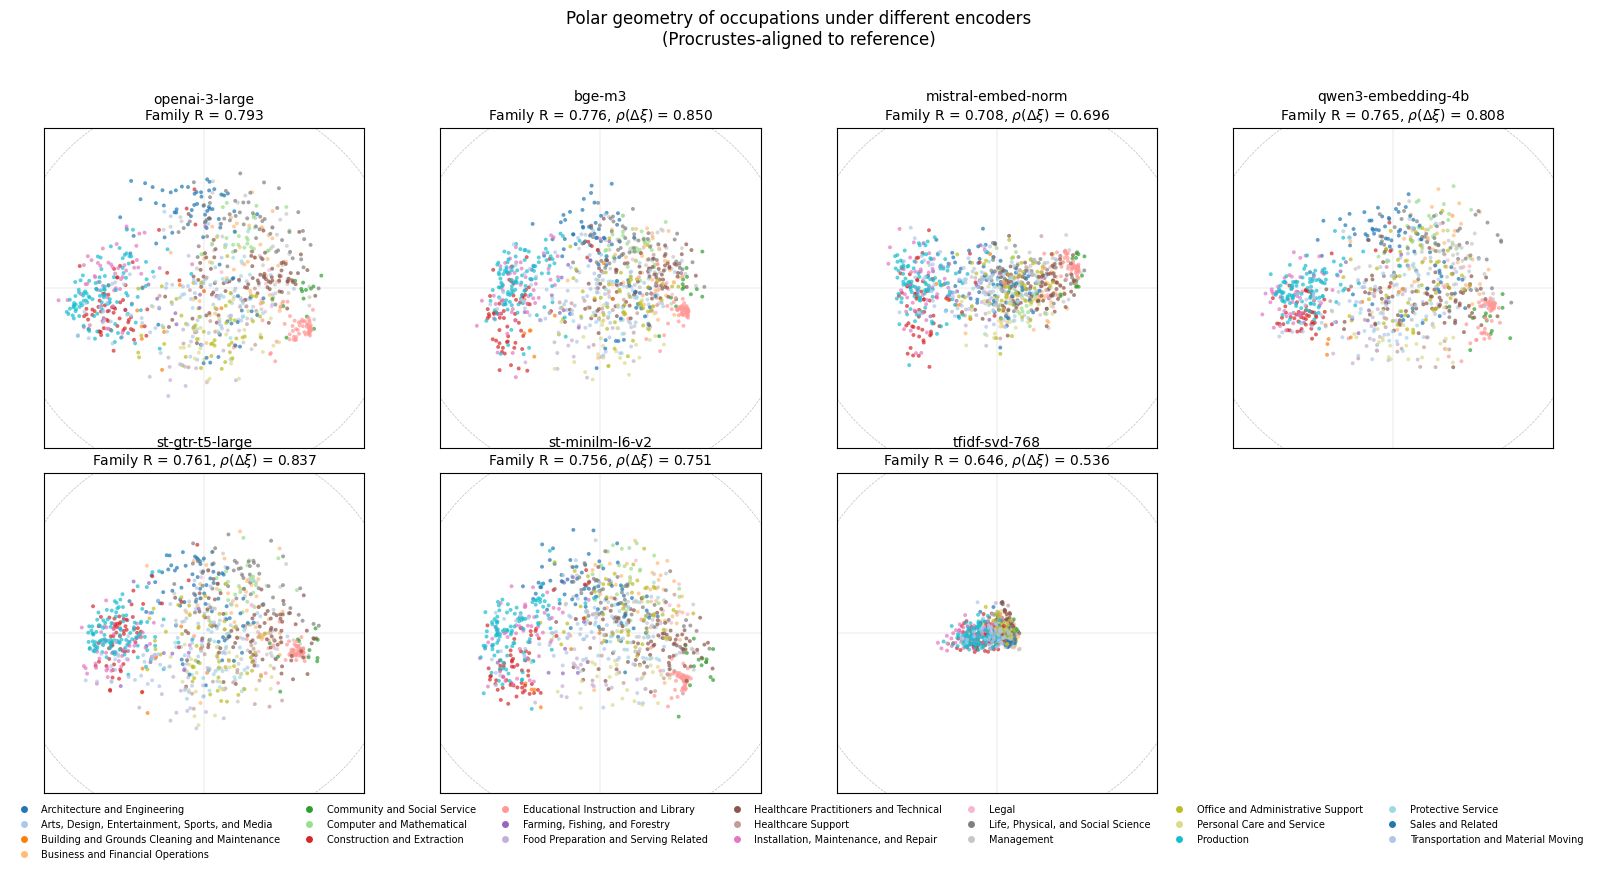

In [17]:
# === Cell 16: Visualize all encoder projections side by side ===
# Diagnostic figure showing the polar geometry under each encoder, aligned
# to the reference via orthogonal Procrustes on occupation centroids.
# This figure is for analysis, not for the paper.

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.linalg import orthogonal_procrustes

# ---------------------------------------------------------------------------
# Load Job Family labels for color coding
# ---------------------------------------------------------------------------
# The job family information should be in one of the run's exports; adjust
# the path below if it lives elsewhere. We use the reference run since
# job families are encoder-independent.
ref_rp = runs_on_disk[REF_ENCODER]
fp_families = ref_rp.export_fp("occupation_embeddings_polar_scaled.csv")
df_fam = pd.read_csv(fp_families, usecols=["onet_code", "Job Family"])
df_fam["onet_code"] = df_fam["onet_code"].astype(str)
fam_map = dict(zip(df_fam["onet_code"], df_fam["Job Family"]))

# Build a stable color palette for job families
unique_families = sorted(set(fam_map.values()))
cmap = plt.cm.tab20
family_colors = {f: cmap(i % 20) for i, f in enumerate(unique_families)}

# ---------------------------------------------------------------------------
# Procrustes alignment: rotate/reflect each encoder's coordinates to
# minimize squared distance to the reference. We work in Cartesian (x, y).
# ---------------------------------------------------------------------------
def polar_to_cart(polar_df):
    xi = polar_df["xi"].to_numpy(float)
    chi = polar_df["chi"].to_numpy(float)
    return np.column_stack([chi * np.cos(xi), chi * np.sin(xi)])

# Reference Cartesian coordinates (no rotation needed)
ref_polar = per_encoder[REF_ENCODER]["polar_aligned"]
ref_xy = polar_to_cart(ref_polar)

aligned_xy = {REF_ENCODER: ref_xy}
for name in encoder_order:
    if name == REF_ENCODER:
        continue
    polar = per_encoder[name]["polar_aligned"]
    xy = polar_to_cart(polar)
    # Procrustes finds rotation R (and allows reflection) such that
    # xy @ R is closest to ref_xy in Frobenius norm.
    R, _scale = orthogonal_procrustes(xy, ref_xy)
    aligned_xy[name] = xy @ R

# ---------------------------------------------------------------------------
# Figure layout: 2 rows x 4 cols for 7 encoders (one cell empty)
# ---------------------------------------------------------------------------
n_enc = len(encoder_order)
ncols = 4
nrows = (n_enc + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 8.5),
                         subplot_kw={"aspect": "equal"})
axes = axes.flatten()

# Find common axis limits across all encoders for fair comparison
all_xy = np.vstack(list(aligned_xy.values()))
lim = np.max(np.abs(all_xy)) * 1.1

# Stats for annotation
stats_lookup = final.to_dict("index")

for ax, name in zip(axes, encoder_order):
    xy = aligned_xy[name]
    polar = per_encoder[name]["polar_aligned"]
    codes = polar["onet_code"].tolist()
    colors = [family_colors.get(fam_map.get(c, "Unknown"), (0.5, 0.5, 0.5, 1.0))
              for c in codes]
    
    # Unit circle for reference
    theta = np.linspace(0, 2 * np.pi, 200)
    ax.plot(np.cos(theta), np.sin(theta), color="gray", linewidth=0.5,
            linestyle="--", alpha=0.5)
    
    # Axes through origin
    ax.axhline(0, color="gray", linewidth=0.3, alpha=0.4)
    ax.axvline(0, color="gray", linewidth=0.3, alpha=0.4)
    
    # Scatter occupations
    ax.scatter(xy[:, 0], xy[:, 1], c=colors, s=8, alpha=0.7,
               edgecolors="none")
    
    # Title and stats
    stats = stats_lookup.get(name, {})
    family_R = stats.get("Family R", float("nan"))
    rho_xi = stats.get("rho(dxi, dxi_ref)", float("nan"))
    
    title = f"{name}\n"
    title += f"Family R = {family_R:.3f}"
    if name != REF_ENCODER:
        title += f", $\\rho(\\Delta\\xi)$ = {rho_xi:.3f}"
    ax.set_title(title, fontsize=10)
    
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_xticks([])
    ax.set_yticks([])

# Hide unused subplots
for ax in axes[n_enc:]:
    ax.set_visible(False)

# Legend for job families (compact, outside the plot grid)
handles = [plt.Line2D([0], [0], marker="o", color="w",
                      markerfacecolor=family_colors[f],
                      markersize=6, label=f)
           for f in unique_families]
fig.legend(handles=handles, loc="lower center",
           ncol=min(7, len(unique_families)),
           fontsize=7, frameon=False, bbox_to_anchor=(0.5, -0.02))

fig.suptitle("Polar geometry of occupations under different encoders\n"
             "(Procrustes-aligned to reference)",
             fontsize=12, y=0.99)
fig.tight_layout(rect=(0, 0.05, 1, 0.96))

# Save to the reference run's figures directory
fig_fp = ref_rp.figure_fp("encoder_projections_comparison.pdf")
fig.savefig(fig_fp, bbox_inches="tight", dpi=200)
fig_fp_png = ref_rp.figure_fp("encoder_projections_comparison.png")
fig.savefig(fig_fp_png, bbox_inches="tight", dpi=150)
print(f"Saved: {fig_fp}")
print(f"Saved: {fig_fp_png}")

plt.show()